In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import tomography_utilities as util

## Set the date for IGRF

In [2]:
date = '2025-02-01'

### We read in the whole IQ stream, then choose the section stream[startind:endind] to analyze. You should choose those indices yourself. Startind should be after spindown and endind should be before signal quality falls too low

In [3]:
# startind = 3125*(2000+0)
startind = 3125*(1200)
endind = 3125*(1200+490)
#startind = 6250*(2158+30)
#endind = 6250*(2158+456)

In [17]:
new_sample_rate = (50/16)*1000

In [4]:
plot = True

In [5]:
# These cut off the FFT to trim out extraneous signals. By default you'd set the first equal to 0, the second to -1
# But you can adjust them to filter out interference
freqcutoffstartind = 0
freqcutoffendind = -1

### Filenames to read in

In [6]:
fname_lav1 = 'data/processed/lav1_processed.bin'
fname_lav2 = 'data/processed/lav2_processed.bin'
fname_yellow1 = 'data/processed/yellow1_processed.bin'
fname_yellow2 = 'data/processed/yellow2_processed.bin'
fname_green1 = 'data/processed/green1_processed.bin'
fname_green2 = 'data/processed/green2_processed.bin'
fname_black1 = 'data/processed/black1_processed.bin'
fname_black2 = 'data/processed/black2_processed.bin'

In [7]:
v = np.fromfile(fname_lav1,dtype=np.complex64)[startind:endind+1]
v2 = np.fromfile(fname_lav2,dtype=np.complex64)[startind:endind+1]
samprate=3125

# Generate time coordinate for the raw signal
sigtime = np.linspace(0,(len(v)-1)/samprate,len(v))

# Define a window for short time fourier transform
w = scipy.signal.windows.hamming(64)
# Define STFT, zero padding fft to get a 512-frequency spectrum despite a 128-sample window
SFT = scipy.signal.ShortTimeFFT(w, hop=32, fft_mode='centered', fs=samprate, mfft=1024, scale_to='magnitude')

# Perform STFT on v and v2
Sx = SFT.stft(v)
Sx2 = SFT.stft(v2)

# Extract frequencies
freqs = SFT.f
time = np.arange(SFT.extent(len(v))[0],SFT.extent(len(v))[1],SFT.delta_t)

In [104]:
import importlib
import tomography_utilities as util
importlib.reload(util)
bounds = util.detect_rogue_crossing(Sx, Sx2, time, freqs, int(len(time)/time[-1]), padding_time=10)

In [105]:
print(time[bounds[0]],time[bounds[1]])

283.98592 324.71040000000005


(283.98592, 324.71040000000005)

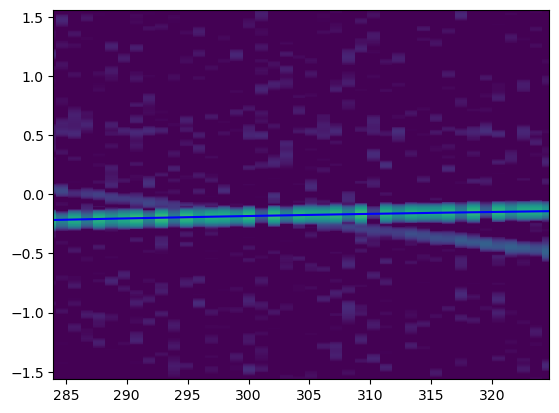

In [107]:
S=np.abs(Sx)
S2=np.abs(Sx2)
bfi = np.argmax(S**2+S2**2,axis=0)
pfit = np.polynomial.polynomial.Polynomial.fit(time, freqs[bfi]/1000, 3)
fitted = pfit(time)

plt.pcolormesh(time[::100],freqs/1000,20*np.log10(S[:,::100]),vmin=-70,vmax=-15,shading='nearest')
#plt.vlines([time[bounds[0]],time[bounds[1]]],-1.5,1.5, colors='r', linestyles='dashed')
plt.plot(time[::100],fitted[::100],'b',label='Fitted')
plt.xlim(time[bounds[0]],time[bounds[1]])

In [16]:
#fft_data = np.array([time, freqs, Sx])
#print(np.array_equal(time, Sx[0:,]))
S = np.abs(Sx)
S2 = np.abs(Sx2)
bfi = np.argmax(S**2+S2**2,axis=0)
pfit = np.polynomial.polynomial.Polynomial.fit(time, bfi, 3)
fitted = pfit(time)
upper_freq_limit = fitted+2*np.std(fitted)
lower_freq_limit = fitted-2*np.std(fitted)
indices_outside_limits = []



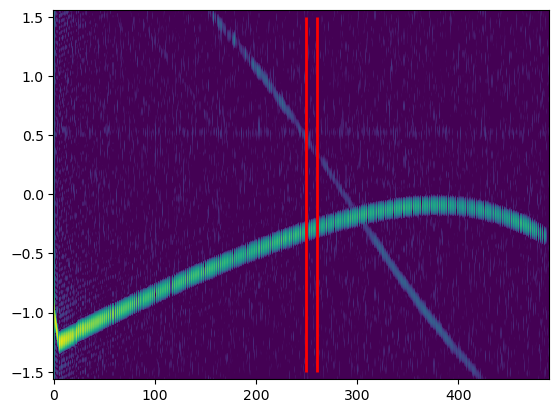

In [ ]:
from skimage.transform import hough_line, hough_line_peaks
from skimage import feature
from scipy.ndimage import gaussian_filter
plt.pcolormesh(time[::100],freqs/1000,20*np.log10(S[:,::100]),vmin=-70,vmax=-15,shading='nearest')
plt.vlines(np.array([time[bounds[0]],time[bounds[1]]]), -1.5,1.5, color='red', linewidth=2)
plt.show()
S_dB = 20 * np.log10(S + 1e-12)  # shift to avoid log(0)
S_blurred = gaussian_filter(S_dB, sigma=25)

edges = feature.canny(S_blurred, sigma=3)
plt.imshow(edges, aspect='auto', origin='lower', cmap='gray')
plt.show()

In [18]:
from skimage.transform import probabilistic_hough_line
lines = probabilistic_hough_line(edges, threshold=10, line_length=3000, line_gap=300)
print(len(lines))
filtered_lines = []
for i in lines:
    x0=i[0][0]
    y0=i[0][1]
    x1=i[1][0]
    y1=i[1][1]
    if np.abs((y1-y0)/(x1-x0))>=0.01:
        filtered_lines.append(i)
print(len(filtered_lines))

121
5


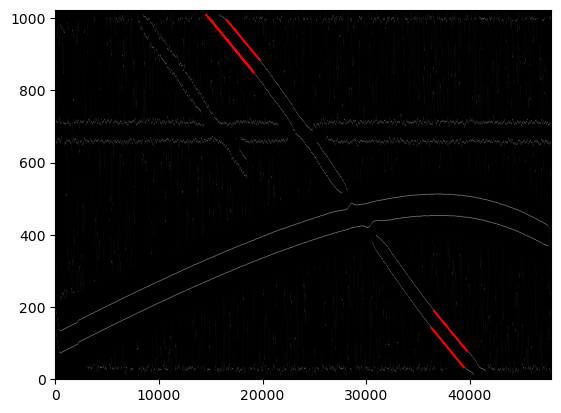

In [47]:
plt.imshow(edges, aspect='auto', origin='lower', cmap='gray')
for i in filtered_lines:
    x0=i[0][0]
    y0=i[0][1]
    x1=i[1][0]
    y1=i[1][1]
    plt.plot((x0,x1),(y0,y1),'-r')

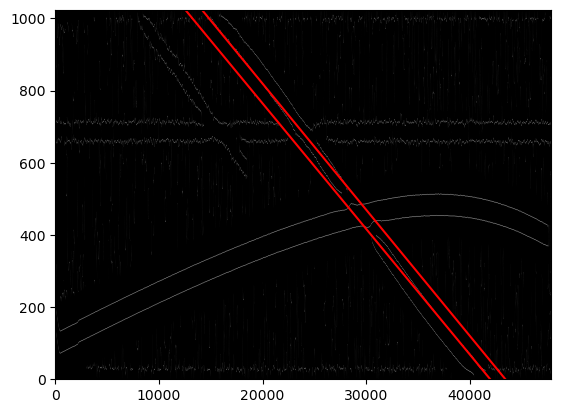

In [58]:
# get functions for lines
class boundary_line:
    def __init__(self, x0,x1,y0,y1, intercept):
        self.x0 = x0
        self.x1 = x1
        self.y0 = y0
        self.y1 = y1
        self.intercept = intercept
        
def get_line_func(x0,y0,x1,y1):
    slope = (y1 - y0) / (x1 - x0)
    intercept = y0 - slope * x0
    return lambda x: slope * x + intercept

line_list = []
for i in filtered_lines:
    tmp = boundary_line(i[0][0],i[1][0],i[0][1],i[1][1],(i[0][1]-i[1][1])/(i[0][0]-i[1][0]))
    line_list.append(tmp)

min_boundary = min(line_list, key=lambda x: x.intercept)
max_boundary = max(line_list, key=lambda x: x.intercept)
xaxis =  np.linspace(0,edges.shape[1],num=40000)
plt.imshow(edges, aspect='auto', origin='lower', cmap='gray')
ax = plt.gca()
min_func = get_line_func(min_boundary.x0,min_boundary.y0,min_boundary.x1,min_boundary.y1)
max_func = get_line_func(max_boundary.x0,max_boundary.y0,max_boundary.x1,max_boundary.y1)
y_min = min_func(xaxis)
y_max = max_func(xaxis)
ax.set_xlim(0, edges.shape[1])
ax.set_ylim(0, edges.shape[0])
ax.plot(xaxis, y_min, '-r')
ax.plot(xaxis, y_max, '-r')


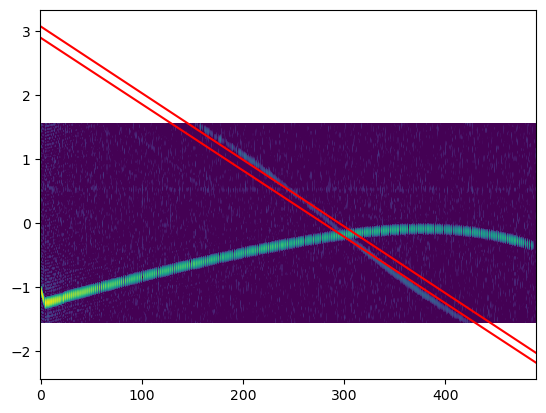

In [ ]:
# convert from pixel to real space
def pixel2real(line, time_arr, freq_arr):
    line.x0 = time_arr[line.x0]
    line.x1 = time_arr[line.x1]
    line.y0 = freq_arr[line.y0]
    line.y1 = freq_arr[line.y1]
    # convert to khz range
    line.y0 = line.y0/1000
    line.y1 = line.y1/1000
    return line
min_boundary = pixel2real(min_boundary, time, freqs)
max_boundary = pixel2real(max_boundary, time, freqs)
# plot the boundary over the spectogram
real_min_func = get_line_func(min_boundary.x0,min_boundary.y0,min_boundary.x1,min_boundary.y1)
real_max_func = get_line_func(max_boundary.x0,max_boundary.y0,max_boundary.x1,max_boundary.y1)
plt.pcolormesh(time[::100],freqs/1000,20*np.log10(np.abs(Sx[:,::100])),vmin=-70,vmax=-15,shading='nearest')
plt.plot(time[::100],real_min_func(time[::100]),'-r')
plt.plot(time[::100],real_max_func(time[::100]),'-r')

## These are all the variables you should (ideally) need to adjust until we have to start reading in GPS data!

### Pull out signal frequency with time, along with tuner1 and tuner2 amplitudes

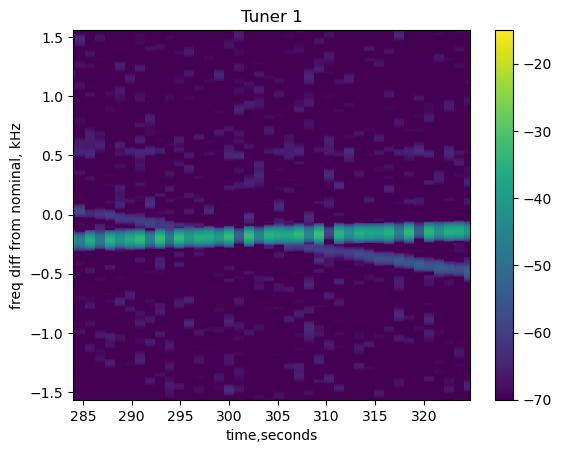

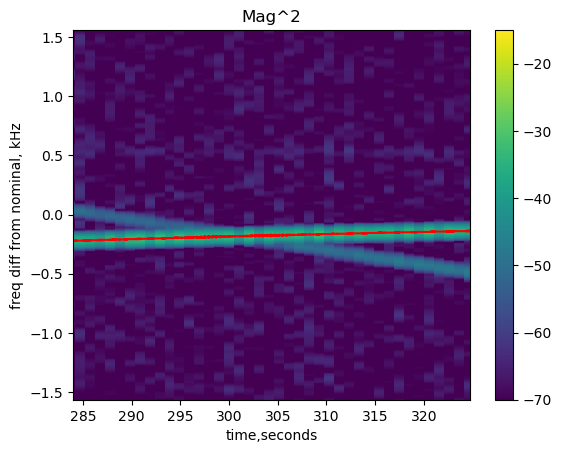

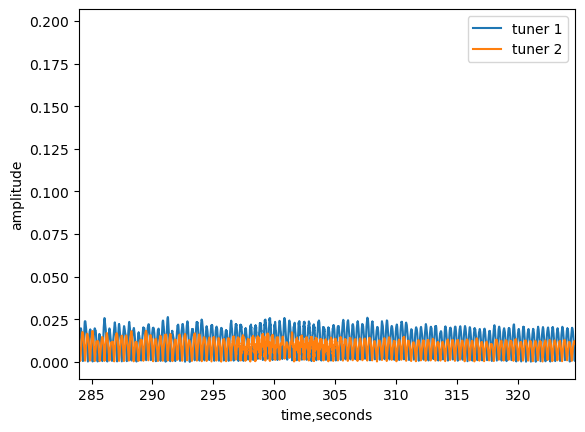

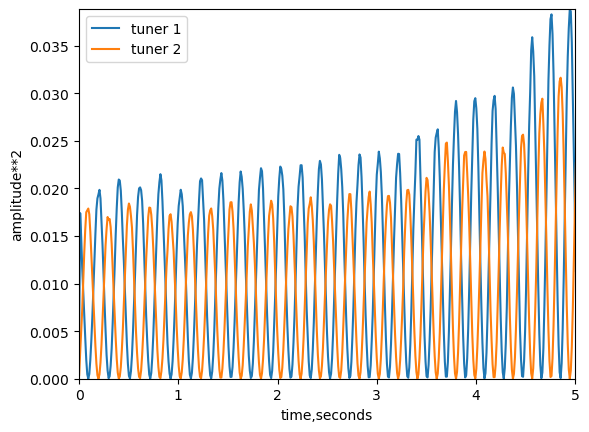

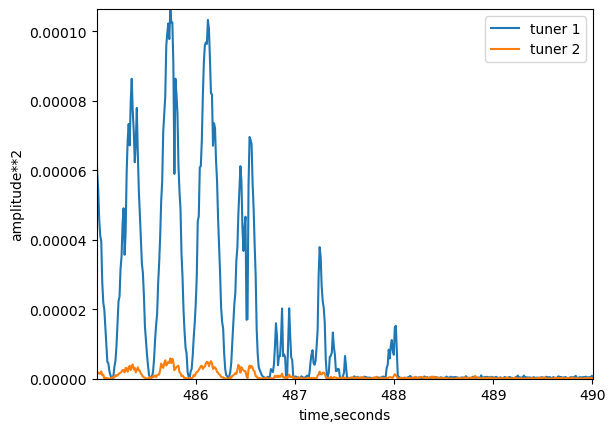

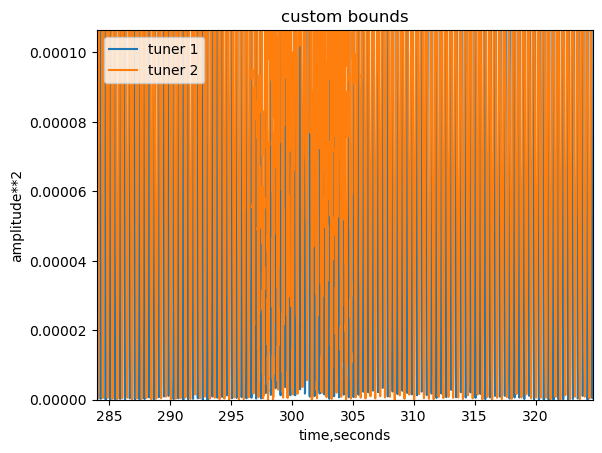

In [ ]:
#time,freqvec_lav,ampvec_lav,ampvec2_lav = extract_intensity_frequency('lav_tuner1_6point25k_25atten_yellowstart.raw','lav_tuner2_6point25k_25atten_yellowstart.raw',startind,endind,6250,plot=plot)
importlib.reload(util)
time,ampvec_lav,ampvec2_lav = util.extract_intensity(fname_lav1,fname_lav2,startind,endind,3125,freqcutoffstartind,freqcutoffendind,plot=plot,300,305)
# pick out something that varies with spin rate and make spectogram for spin rate as f of time

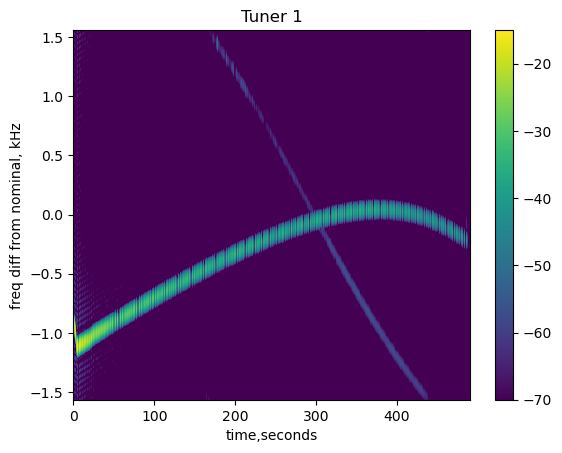

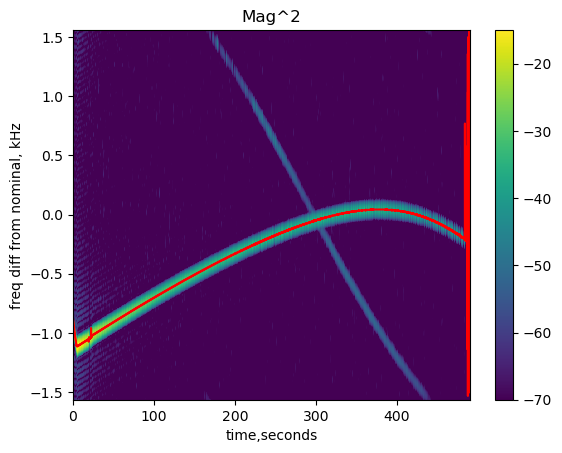

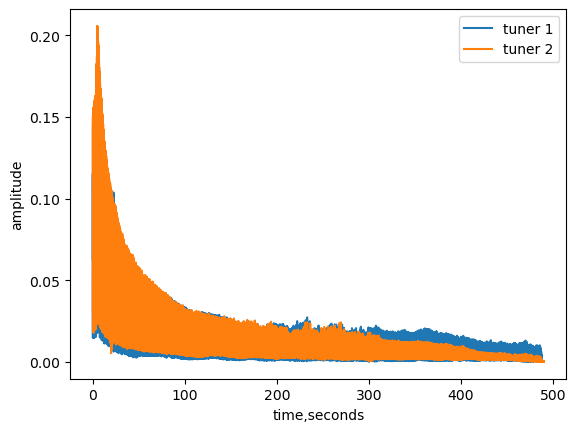

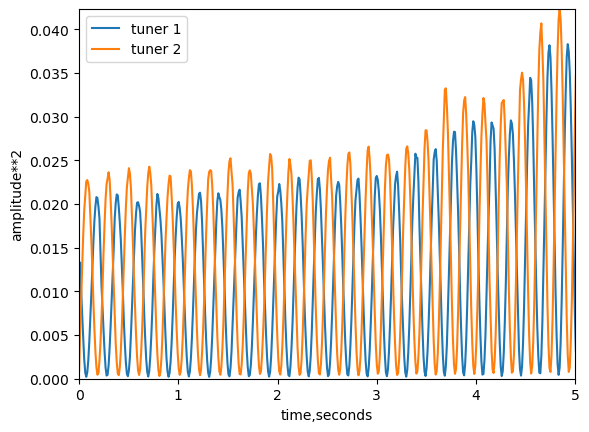

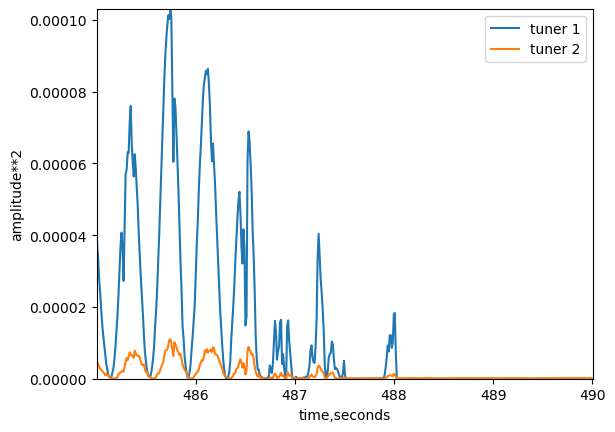

In [11]:
_,ampvec_yellow,ampvec2_yellow = extract_intensity(fname_yellow1,fname_yellow2,startind,endind,3125,freqcutoffstartind,freqcutoffendind,plot=plot)

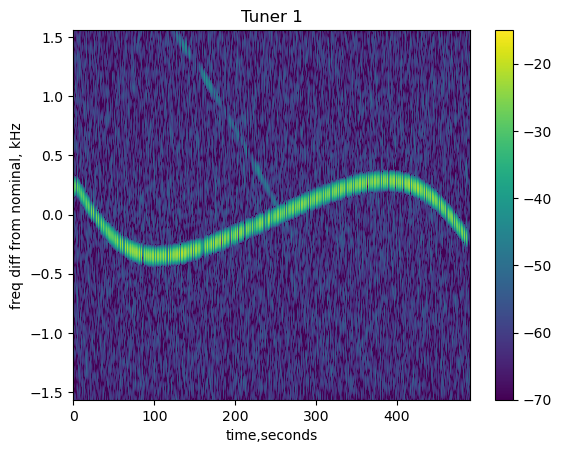

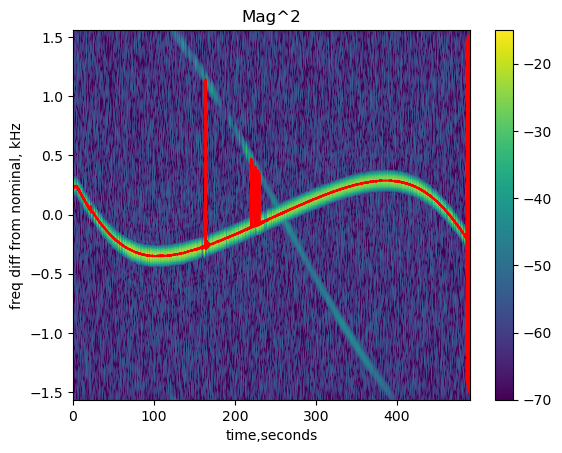

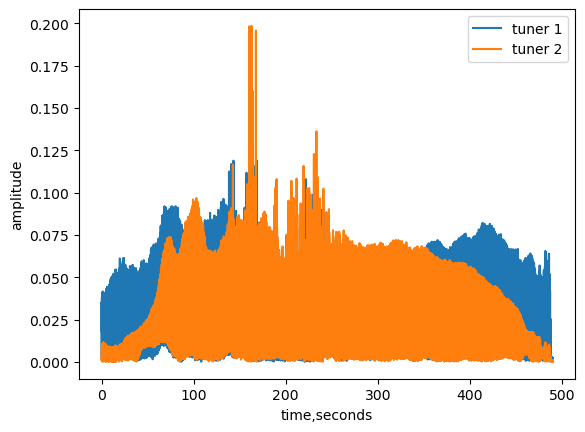

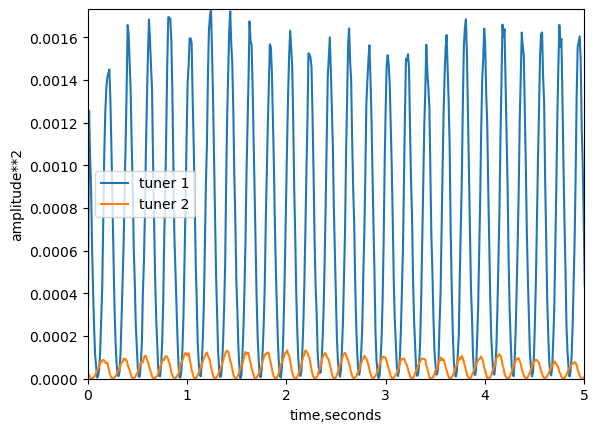

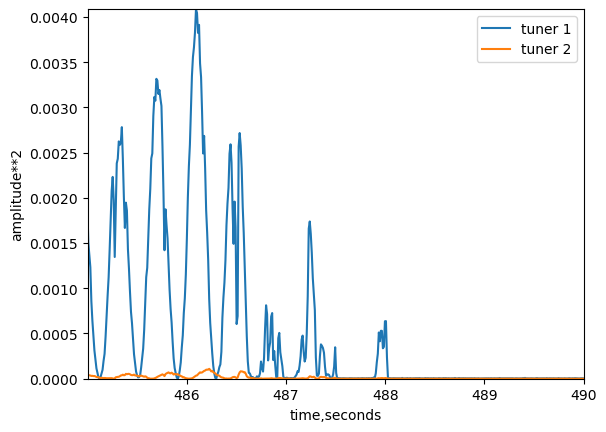

In [ ]:
_,ampvec_green,ampvec2_green = util.extract_intensity(fname_green1,fname_green2,startind,endind,3125,freqcutoffstartind,freqcutoffendind,plot=plot)

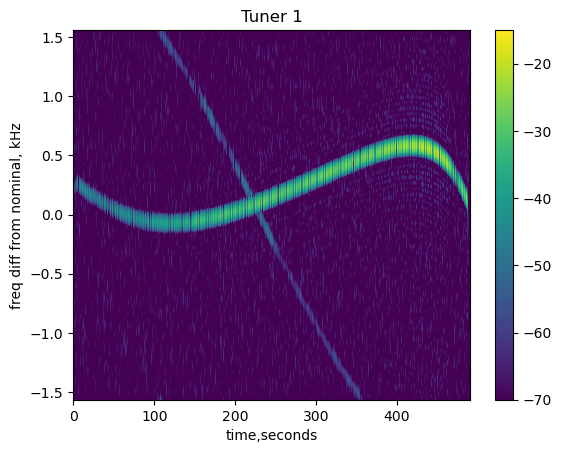

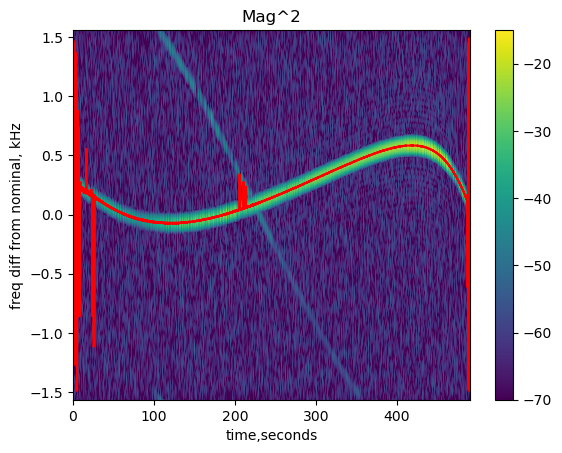

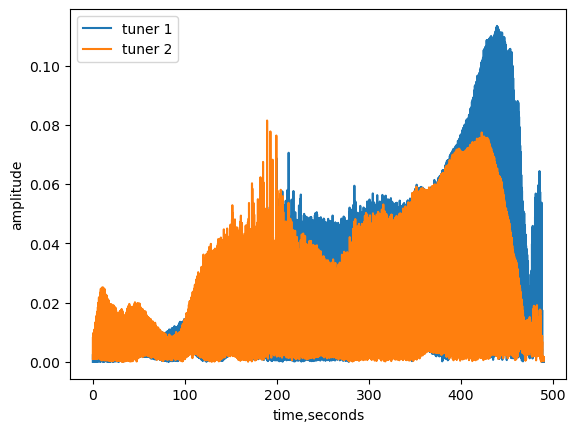

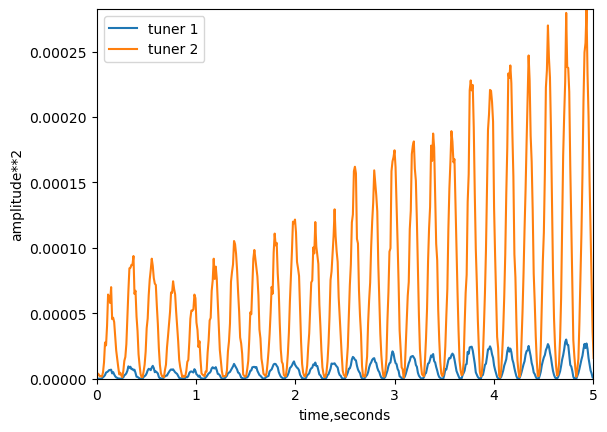

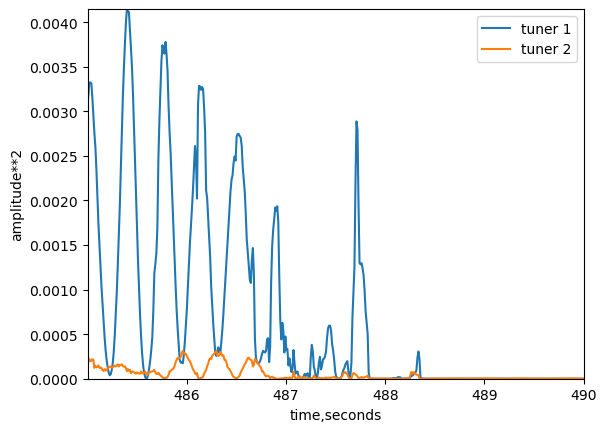

In [13]:
_,ampvec_black,ampvec2_black = extract_intensity(fname_black1,fname_black2,startind,endind,3125,freqcutoffstartind,freqcutoffendind,plot=plot)

In [12]:
plot = True

## High pass filter amplitudes, then divide by sqrt(amp_tuner1^2 + amp_tuner2^2)

## Pay attention to these plots - where the curves look nice and sinusoidal, data are reliable. Where they look weird, don't trust it! (Yet, I'm working on it...)

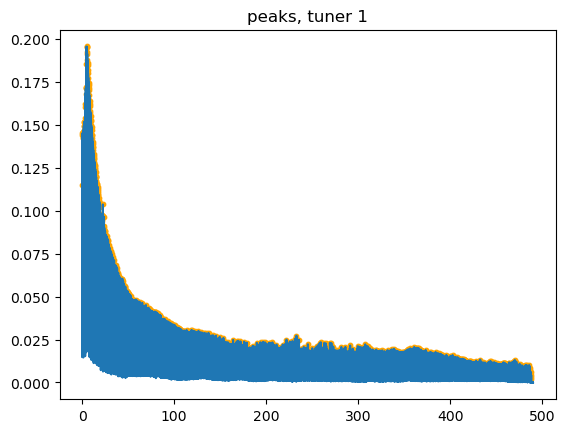

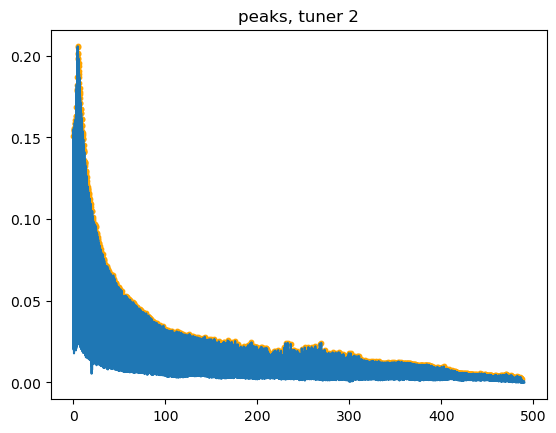

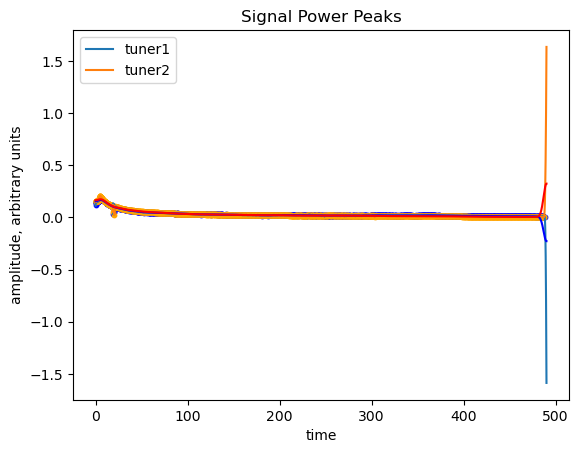

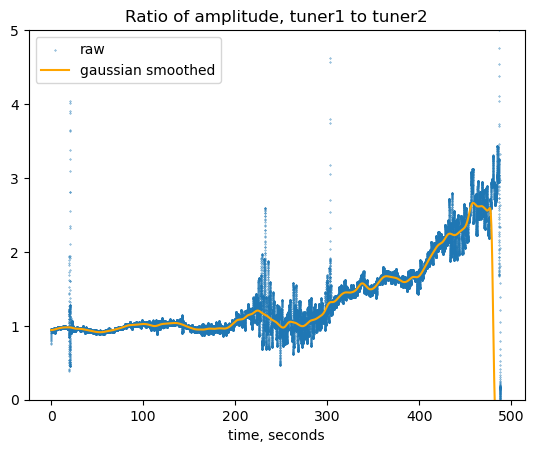

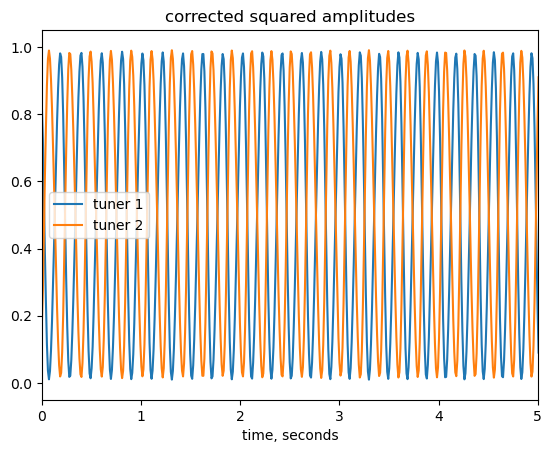

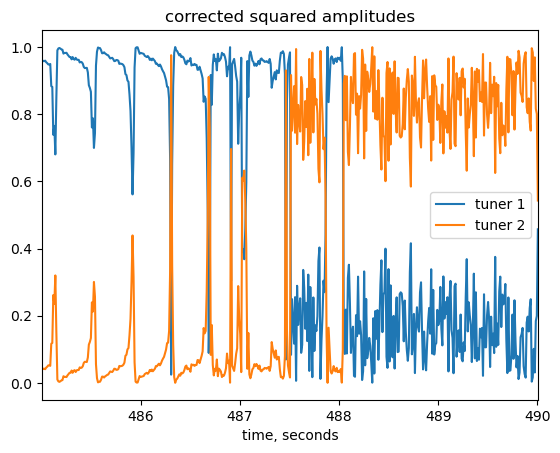

In [ ]:
ampnorm_yellow,amp2norm_yellow,envy1,envy2 = util.normalize_amplitudes(time,ampvec_yellow,ampvec2_yellow,plot=plot)

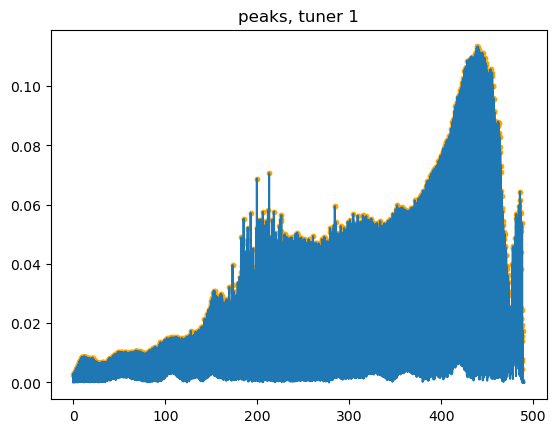

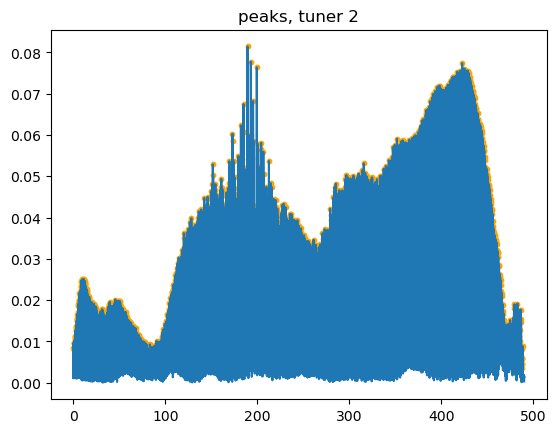

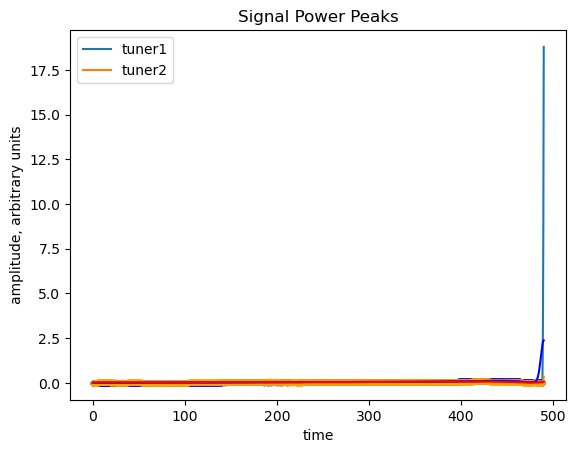

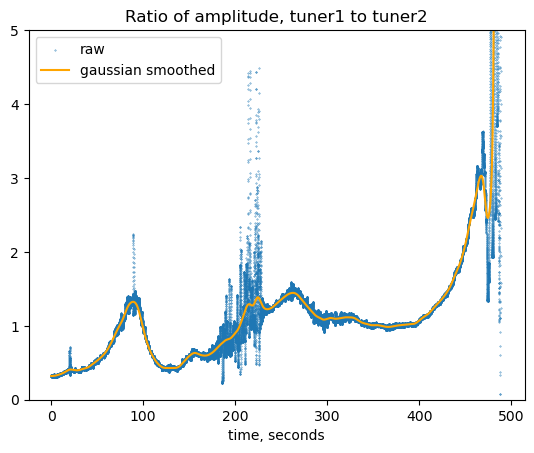

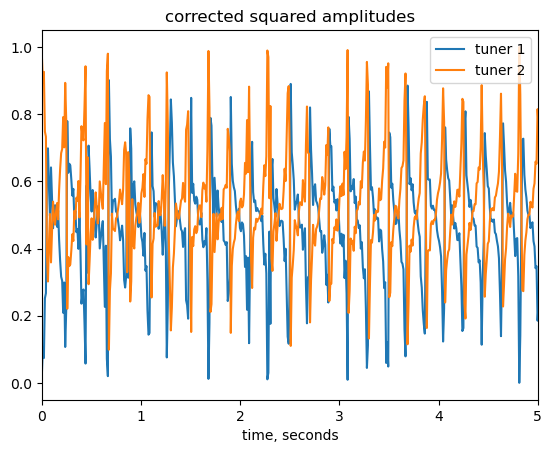

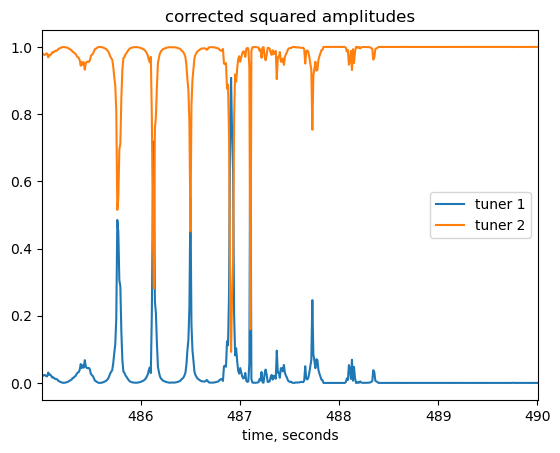

In [ ]:
ampnorm_black,amp2norm_black,envb1,envb2 = util.normalize_amplitudes(time,ampvec_black,ampvec2_black,plot=plot)

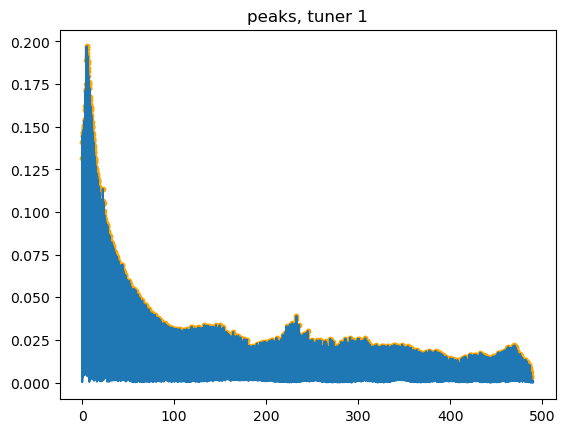

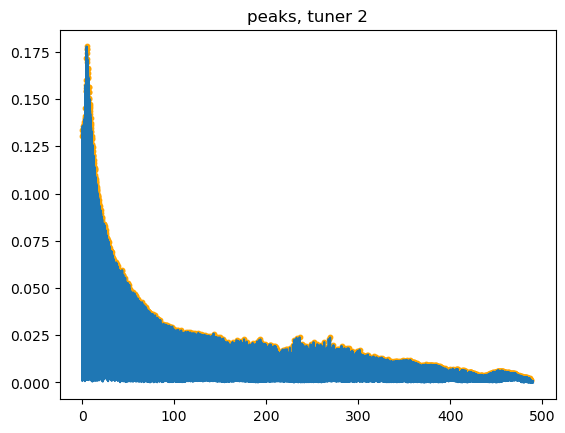

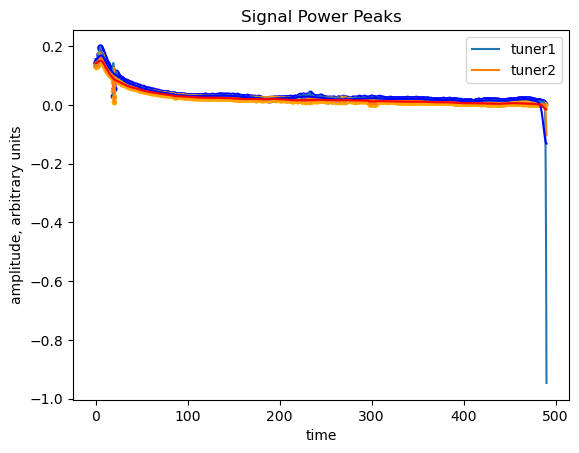

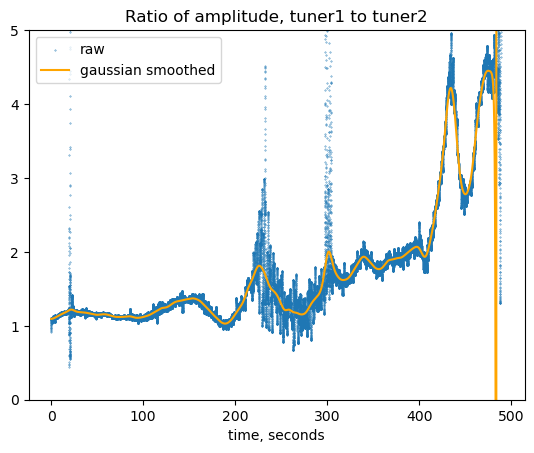

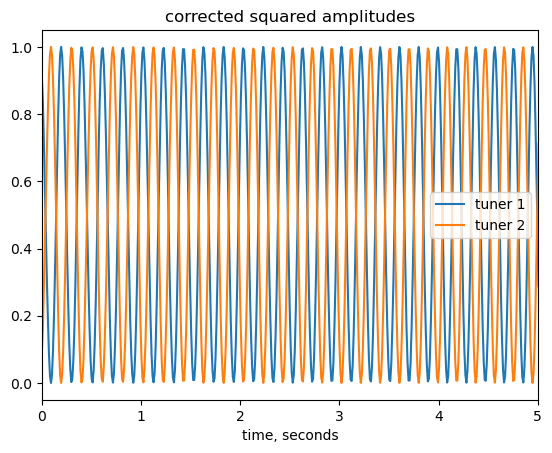

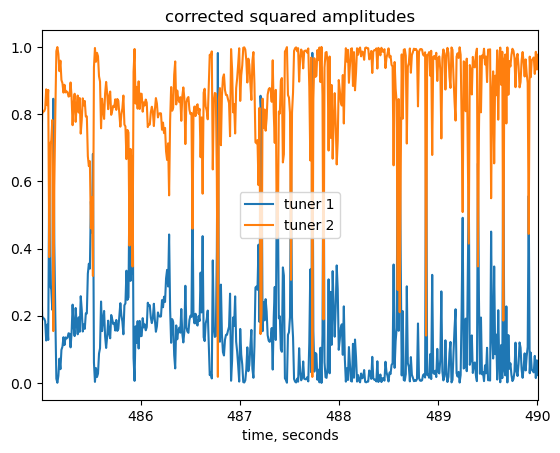

In [ ]:
ampnorm_lav,amp2norm_lav,envl1,envl2 = util.normalize_amplitudes(time,ampvec_lav,ampvec2_lav,plot=plot)

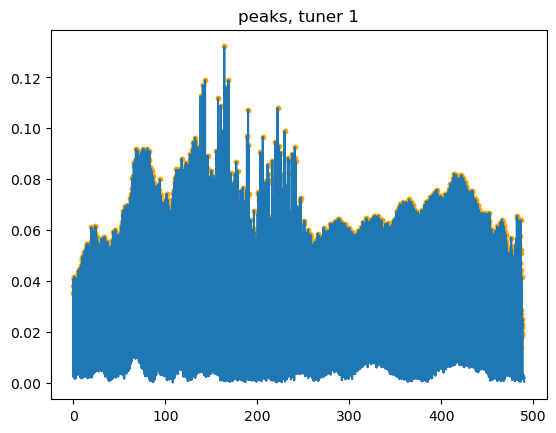

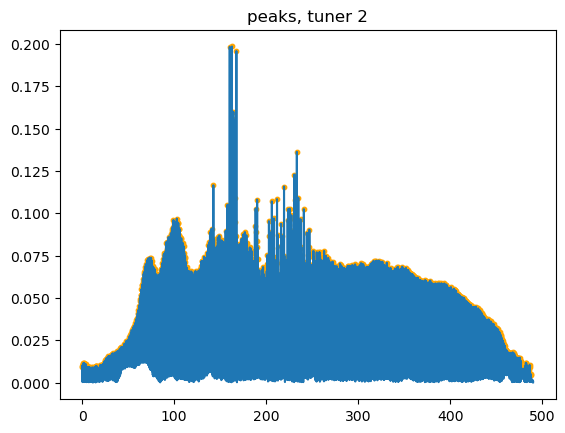

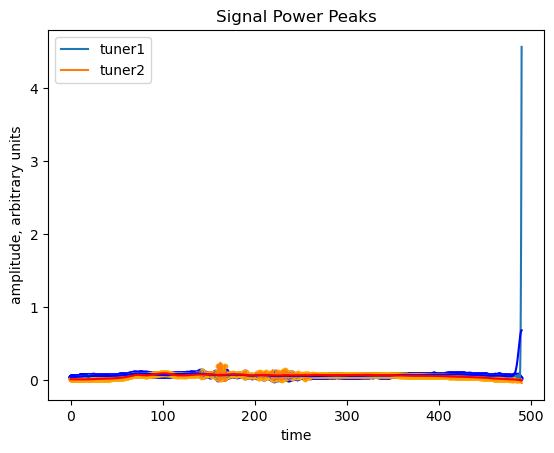

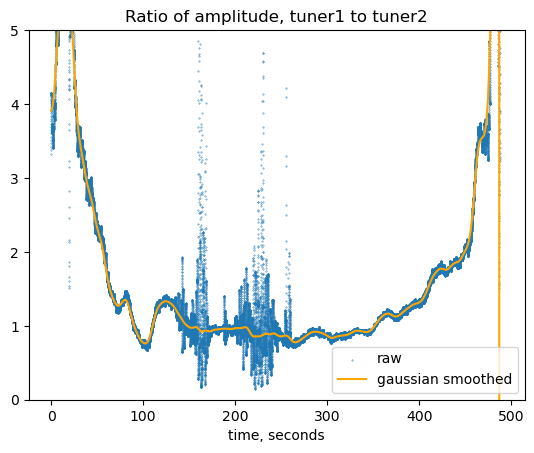

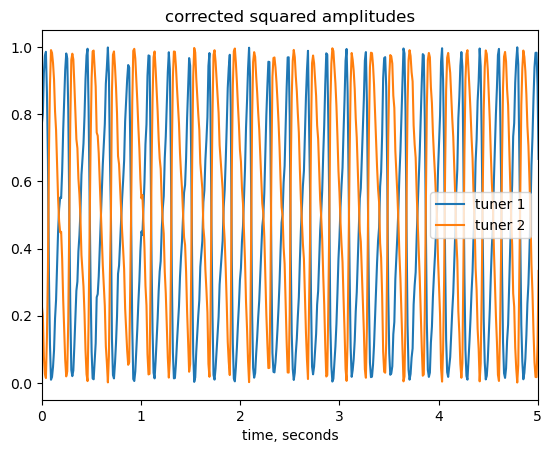

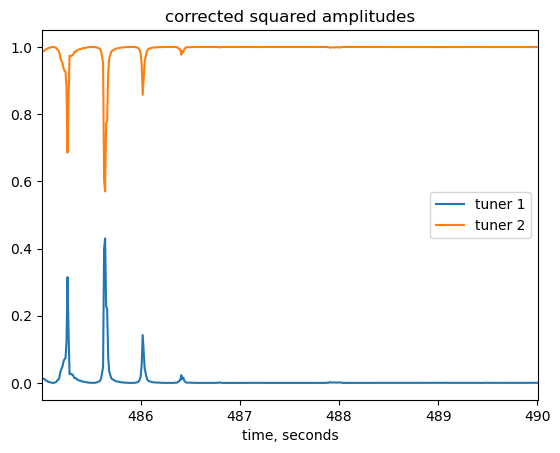

In [ ]:
ampnorm_green,amp2norm_green,envg1,envg2 = util.normalize_amplitudes(time,ampvec_green,ampvec2_green,plot=plot)

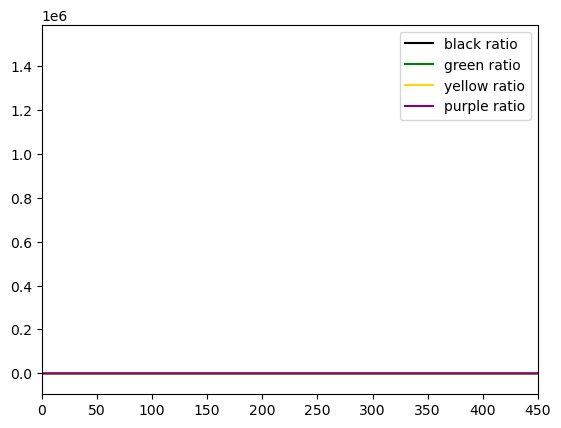

In [21]:
plt.plot(time,envb1/envb2,color='black',label='black ratio')
plt.plot(time,envg1/envg2,color='green',label='green ratio')
plt.plot(time,envy1/envy2,color='gold',label='yellow ratio')
plt.plot(time,envl1/envl2,color='purple',label='purple ratio')

plt.xlim(0,450)
plt.legend()

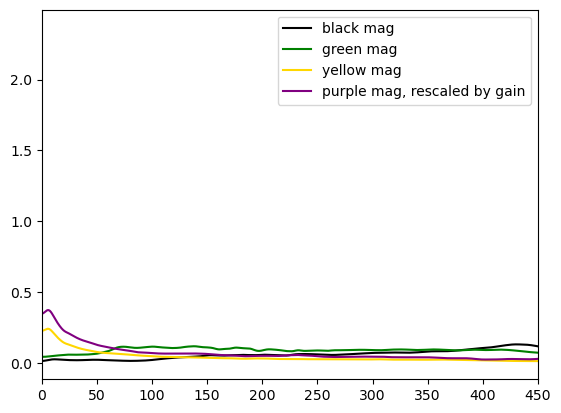

In [20]:
plt.plot(time,np.sqrt(envb1**2 + envb2**2),color='black',label='black mag')
plt.plot(time,np.sqrt(envg1**2 + envg2**2),color='green',label='green mag')
plt.plot(time,np.sqrt(envy1**2 + envy2**2),color='gold',label='yellow mag')
plt.plot(time,np.sqrt(envl1**2 + envl2**2)*1.6487212707,color='purple',label='purple mag, rescaled by gain')
plt.xlim(0,450)

plt.legend()

## Currently bounds are set to between 1 and 2 Hz (the frequency we see is doubled!)

(1.2, 1.3)

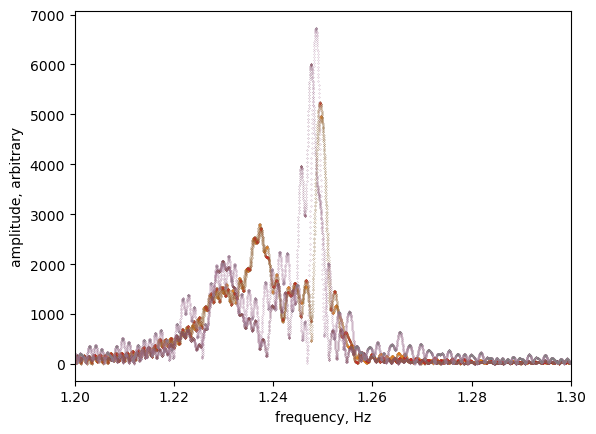

In [ ]:
bestfreqlav1 = util.fftpeak(ampnorm_lav**2 - np.mean(ampnorm_lav**2),np.diff(time)[0],2,4)
bestfreqlav2 = util.fftpeak(amp2norm_lav**2 - np.mean(ampnorm_lav**2),np.diff(time)[0],2,3)

bestfreqyellow1 = util.fftpeak(ampnorm_yellow**2 - np.mean(ampnorm_yellow**2),np.diff(time)[0],2,4)
bestfreqyellow2 = util.fftpeak(amp2norm_yellow**2 - np.mean(ampnorm_yellow**2),np.diff(time)[0],2,4)

bestfreqblack1 = util.fftpeak(ampnorm_black**2 - np.mean(ampnorm_black**2),np.diff(time)[0],2,4)
bestfreqblack2 = util.fftpeak(amp2norm_black**2 - np.mean(ampnorm_black**2),np.diff(time)[0],2,4)

bestfreqgreen1 = util.fftpeak(ampnorm_green**2 - np.mean(ampnorm_green**2),np.diff(time)[0],2,4)
bestfreqgreen2 = util.fftpeak(amp2norm_green**2 - np.mean(ampnorm_green**2),np.diff(time)[0],2,4)

plt.xlabel('frequency, Hz')
plt.ylabel('amplitude, arbitrary')
plt.xlim(1.2,1.3)

In [24]:
freqvec = [bestfreqlav1,bestfreqlav2,bestfreqyellow1,bestfreqyellow2,bestfreqblack1,bestfreqblack2,bestfreqgreen1,bestfreqgreen2]

In [25]:
print(str(np.round(np.mean(freqvec)/2,5))+' +/- '+str(np.format_float_positional(np.round(np.std(freqvec),5)))+' Hz')
print('best spin frequency fit')

print('don\'t trust those error bounds, properly I\'d find the spread of each distribution!')

1.24882 +/- 0.0016 Hz
best spin frequency fit
don't trust those error bounds, properly I'd find the spread of each distribution!


Text(0, 0.5, 'Faraday Rotation angle, radians')

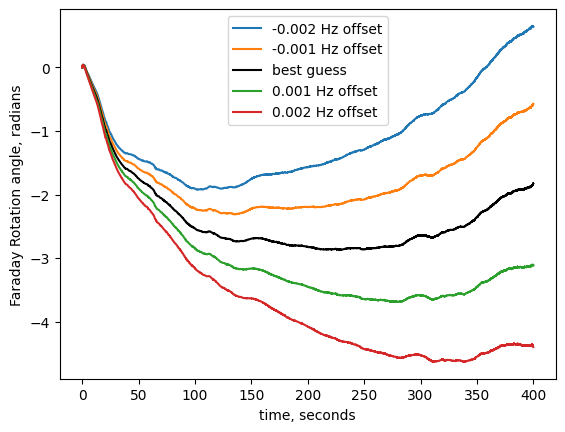

In [ ]:
goodf = util.wavelet_extractphase_uniformfreq(time,ampnorm_lav**2,np.sin(2*np.pi*np.mean(freqvec)*time),plot=False)
#plt.plot(time,goodf-goodf[0],color='black',label='best guess spin rate',zorder=100)

freqlist = np.linspace(np.mean(freqvec)-0.002,np.mean(freqvec)+0.002,5)

for i in range(len(freqlist)):
    f = util.wavelet_extractphase_uniformfreq(time,ampnorm_lav**2,np.sin(freqlist[i]*2*np.pi*time),plot=False)
    if i ==2:
        plt.plot(time,0.5*(f-f[0]),label='best guess',color='black')
    else:
        plt.plot(time,0.5*(f-f[0]),label=str(np.round(freqlist[i]-np.mean(freqvec),3))+' Hz offset')
plt.legend()
plt.xlabel('time, seconds')
plt.ylabel('Faraday Rotation angle, radians')

## Calculate the reference sinusoid

In [28]:
refphase = np.mean(freqvec)*2*np.pi*time
ref = np.sin(refphase)

In [29]:
plot = True

## Use the CWT to calculate phase offsets

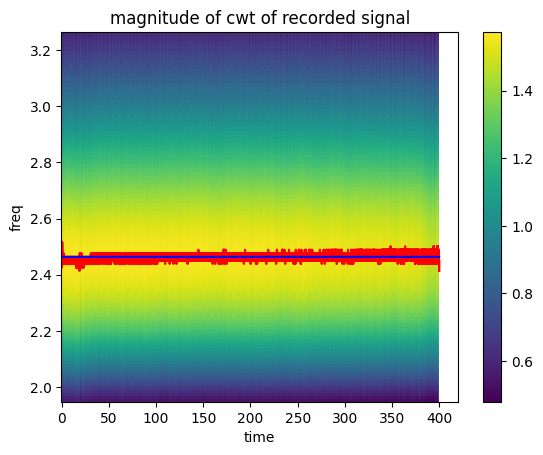

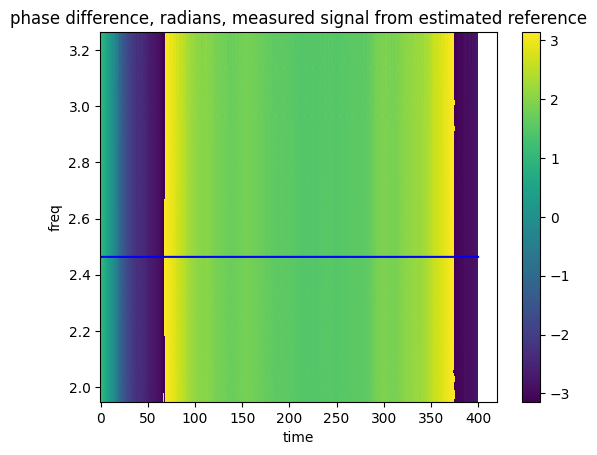

In [ ]:
phaseoff_lav = util.wavelet_extractphase_uniformfreq(time,ampnorm_lav**2,ref,plot=plot)
#phaseoff_lav_new = wavelet_extractphase_uniformfreq(time,ampnorm_lav**2,ref,plot=plot)

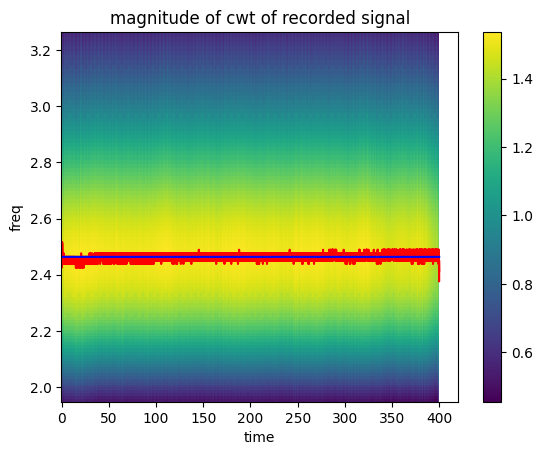

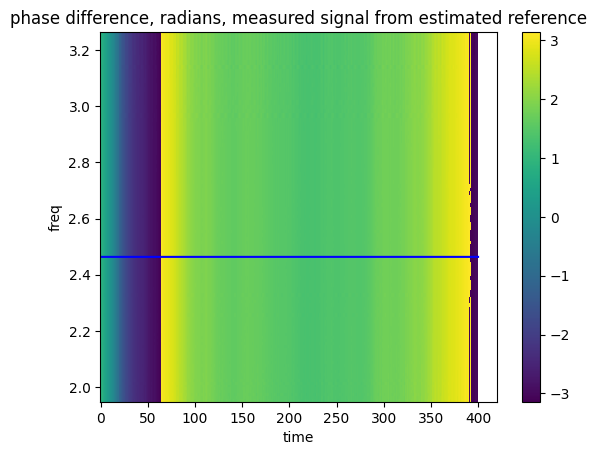

In [ ]:
phaseoff_yellow = util.wavelet_extractphase_uniformfreq(time,ampnorm_yellow**2,ref,plot=plot)

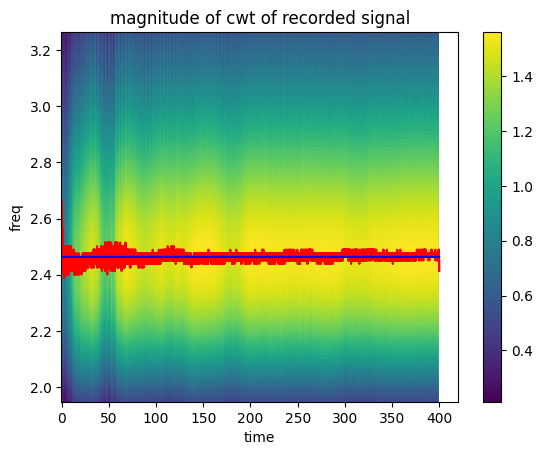

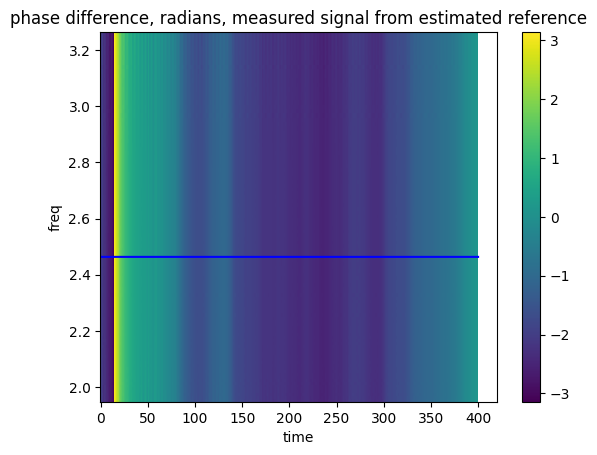

In [ ]:
phaseoff_black = util.wavelet_extractphase_uniformfreq(time,ampnorm_black**2,ref,plot=plot)

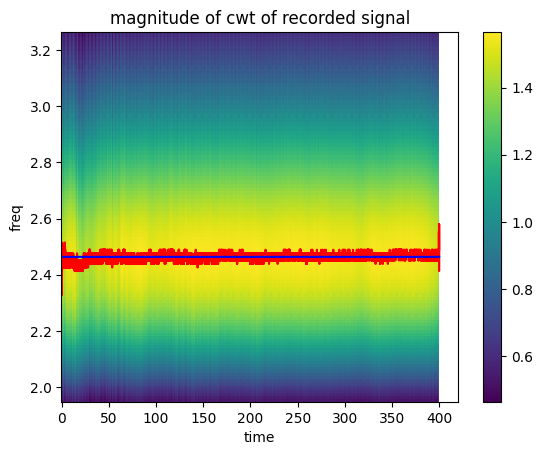

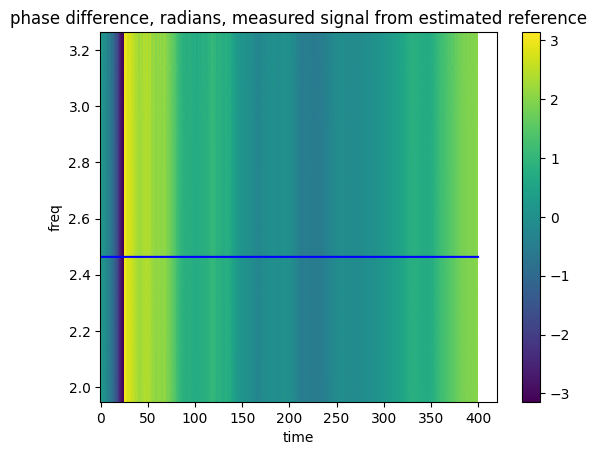

In [ ]:
phaseoff_green = util.wavelet_extractphase_uniformfreq(time,ampnorm_green**2,ref,plot=plot)

Text(0.5, 0, 'time, arbitrary start')

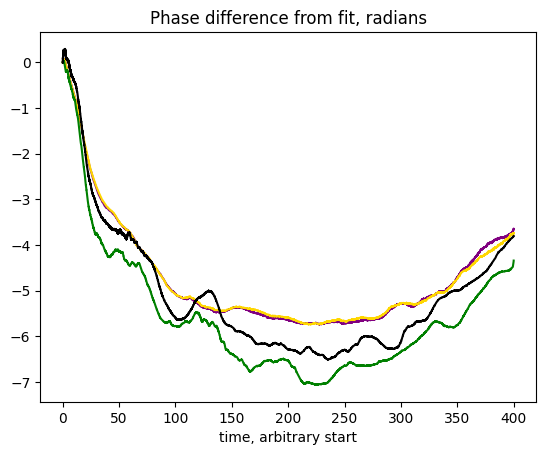

In [34]:
plt.plot(time,phaseoff_lav-phaseoff_lav[0],color='purple')
plt.plot(time,phaseoff_yellow-phaseoff_yellow[0],color='gold')
plt.plot(time,phaseoff_green-phaseoff_green[0],color='green')
plt.plot(time,phaseoff_black-phaseoff_black[0],color='black')
plt.title('Phase difference from fit, radians')
plt.xlabel('time, arbitrary start')

In [35]:
# Calculate best fit parabola

In [36]:
c_0, m_0, b_0 = np.polyfit([*time,*time,*time], [*(phaseoff_lav-phaseoff_lav[0]+phaseoff_yellow-phaseoff_yellow[0])/2,*(phaseoff_black-phaseoff_black[0]),*(phaseoff_green-phaseoff_green[0])], 2)

In [37]:
bestfitparab = 90*(c_0*time**2 + m_0*time + b_0)/np.pi

Text(0.5, 1.0, 'best fit parabola')

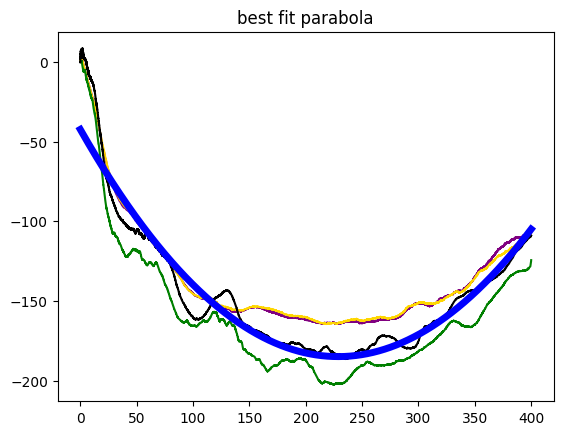

In [38]:
plt.plot(time,90*(phaseoff_lav-phaseoff_lav[0])/np.pi,color='purple')
plt.plot(time,90*(phaseoff_yellow-phaseoff_yellow[0])/np.pi,color='gold')
plt.plot(time,90*(phaseoff_green-phaseoff_green[0])/np.pi,color='green')
plt.plot(time,90*(phaseoff_black-phaseoff_black[0])/np.pi,color='black')
plt.plot(time,bestfitparab,linewidth=5,color='blue')
plt.title('best fit parabola')

In [ ]:

timevec,freqslav = util.stft_times(time,ampnorm_lav**2-np.mean(ampnorm_lav**2))
_,freqsyellow = util.stft_times(time,ampnorm_yellow**2-np.mean(ampnorm_yellow**2))
_,freqsblack = util.stft_times(time,ampnorm_black**2-np.mean(ampnorm_black**2))
_,freqsgreen = util.stft_times(time,ampnorm_green**2-np.mean(ampnorm_green**2))

meanfreqs = np.mean([freqslav,freqsyellow,freqsblack,freqsgreen],axis=0)

Text(0, 0.5, 'frequency, Hz')

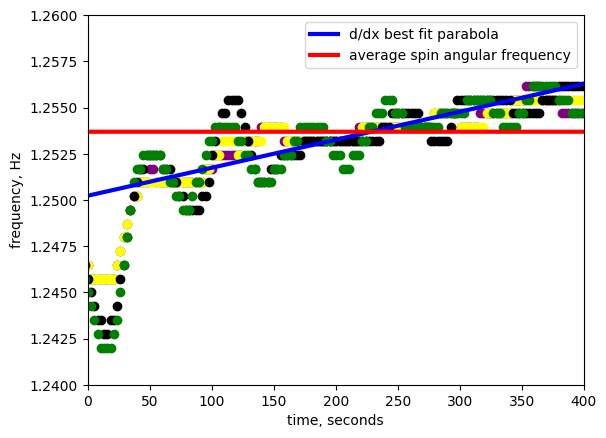

In [40]:
plt.scatter(timevec,(freqslav)/2,color='purple')
plt.scatter(timevec,(freqsyellow)/2,color='yellow')

plt.scatter(timevec,freqsblack/2,color='black')
plt.scatter(timevec,freqsgreen/2,color='green')


plt.plot(time,(2*c_0*time/(2*np.pi) + m_0/(2*np.pi) + np.mean(freqvec))/2,label='d/dx best fit parabola',linewidth=3,color='blue')
plt.plot(time,(0*time+np.mean(freqvec))/2,label='average spin angular frequency',linewidth=3,color='red')
plt.legend()
plt.ylim(1.24,1.26)
plt.xlim(time[0],time[-1])
plt.xlabel('time, seconds')
plt.ylabel('frequency, Hz')

# Read in GPS! Stop here if you don't have it

In [41]:
v = np.genfromtxt('../36381_MAIN_PAYLOAD_GPS.csv',delimiter=',',skip_header=1,dtype=float)[843:10092,:-1]
vhead = np.genfromtxt('../36381_MAIN_PAYLOAD_GPS.csv',delimiter=',',skip_header=0,dtype=str)[0,:-1]

# T=0 for rocket is at 7:07:15 UTC.

In [45]:
# Seconds past midnight, start of "time" variable in this notebook
t1 = 6*60*60 + 32*60 + 14 + startind/3125
# Seconds past midnight, start of gps track:
t0 = 7*60*60 + 7*60 + 15
#print(t1-t0)

In [46]:
# Adjusting time to start at rocket launch
flighttime_radio = (t1-t0)+np.copy(time)
# Extracting time coordinate for rocket flight path
flighttime_gps = v[:,0]

Text(0.5, 1.0, 'Faraday Rotation angle and rocket altitude')

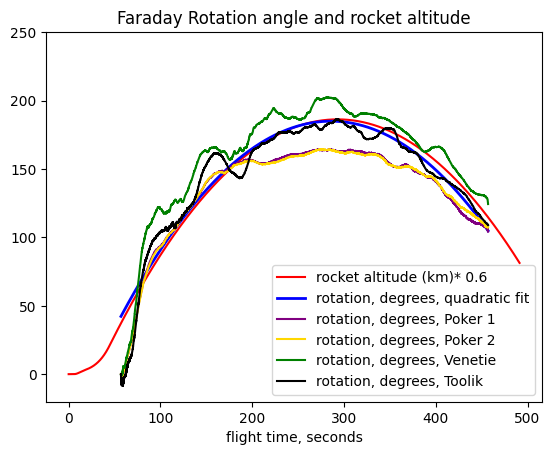

In [47]:
plt.plot(flighttime_gps,v[:,9]*0.6,label='rocket altitude (km)* 0.6', color='red')
plt.plot(flighttime_radio,-bestfitparab,linewidth=2,color='blue',label='rotation, degrees, quadratic fit')


plt.plot(flighttime_radio,-90*(phaseoff_lav-phaseoff_lav[0])/np.pi,color='purple',label='rotation, degrees, Poker 1')
plt.plot(flighttime_radio,-90*(phaseoff_yellow-phaseoff_yellow[0])/np.pi,color='gold',label='rotation, degrees, Poker 2')
plt.plot(flighttime_radio,-90*(phaseoff_green-phaseoff_green[0])/np.pi,color='green',label='rotation, degrees, Venetie')
plt.plot(flighttime_radio,-90*(phaseoff_black-phaseoff_black[0])/np.pi,color='black',label='rotation, degrees, Toolik')


plt.ylim(-20,250)
#plt.xlim(flighttime_radio[0],flighttime_radio[-1])
plt.xlabel('flight time, seconds')
plt.legend()
plt.title('Faraday Rotation angle and rocket altitude')
#plt.plot(time,90*(c_0*time**2 + m_0*time + b_0)/np.pi,linewidth=5,color='blue')

In [48]:
# Let's start estimating B field

In [49]:
import igrf

In [50]:
# As a sanity check: we find magnetic field strength/angle near the barycenter of the trajectory and calculate B// dL and such based on that
zeroorder_igrf = igrf.igrf(date,glat=66.9,glon=-146.96,alt_km=123.4)

# Extract magnitude, inclination, declination
Bmag = np.asarray(zeroorder_igrf.total)[0]
inc = np.asarray(zeroorder_igrf.incl)[0]
decl = np.asarray(zeroorder_igrf.decl)[0]

In [51]:
# To start, we will take B to be uniform and make a flat earth approximation.
# This can be easily fixed later but the vector algebra will be challenging and error prone
# Good to have a zeroth order estimate
# We invent a new flat earth based coordinate system, Venetie centered Venitie Fixed
# x points north, y points west, z points up, center at Venitie
# 67.0161° N, 146.4195° W


In [ ]:
#endind = np.where(flighttime_radio <= flighttime_gps[-1])[0][-1]
# # Resample rocket alt,lat,lon onto radio time coordinate
# altresamp = scipy.interpolate.CubicSpline(flighttime_gps,v[:,9])(flighttime_radio[:endind])
# latresamp = scipy.interpolate.CubicSpline(flighttime_gps,v[:,7])(flighttime_radio[:endind])
# lonresamp = scipy.interpolate.CubicSpline(flighttime_gps,v[:,8])(flighttime_radio[:endind])
# Finding rocket coords
#newx_rocket,newy_rocket,newz_rocket = vcvf(latresamp,lonresamp,altresamp)


newx_rocketfull,newy_rocketfull,newz_rocketfull = util.vcvf(v[:,7],v[:,8],v[:,9])

# Finding coords of other sites:
pkr_x,pkr_y,_ = util.vcvf(65.1256,-147.4919,0)
vee_x,vee_y,_ = util.vcvf(67.0161,-146.4195,0)
too_x,too_y,_ = util.vcvf(68.6318,-149.6060,0)

In [ ]:
fit = False

# Use parabolic/linear fit to estimate rocket trajectory outside bounds
if fit:
    #startind = 1000
    startind = np.where(flighttime_gps >= flighttime_radio[0])[0][0]

    # Quadratic fit of z
    c_z, m_z, b_z = np.polyfit(flighttime_gps[startind:], newz_rocketfull[startind:], 2)
    # Linear fit of x,y
    m_x, b_x = np.polyfit(flighttime_gps[startind:], newx_rocketfull[startind:], 1)
    m_y, b_y = np.polyfit(flighttime_gps[startind:], newy_rocketfull[startind:], 1)
    
    plt.scatter(flighttime_gps[startind:],newz_rocketfull[startind:],s=1)
    plt.plot(flighttime_radio,c_z*flighttime_radio**2 + m_z*flighttime_radio + b_z,color='orange')
    
    plt.scatter(flighttime_gps[startind:],newx_rocketfull[startind:],s=1)
    plt.plot(flighttime_radio,m_x*flighttime_radio + b_x,color='blue')
    
    plt.scatter(flighttime_gps[startind:],newy_rocketfull[startind:],s=1)
    plt.plot(flighttime_radio,m_y*flighttime_radio + b_y,color='red')

    # New coords
    newx_rocket,newy_rocket,newz_rocket = m_x*flighttime_radio + b_x, m_y*flighttime_radio + b_y, c_z*flighttime_radio**2 + m_z*flighttime_radio + b_z
    latresamp,lonresamp,altresamp = util.vcvf_to_lla(newx_rocket,newy_rocket,newz_rocket)
# Simply resample rocket trajectory onto radio time coord
else:
    # Resample with cubic spline
    altresamp = scipy.interpolate.CubicSpline(flighttime_gps,v[:,9])(flighttime_radio)
    latresamp = scipy.interpolate.CubicSpline(flighttime_gps,v[:,7])(flighttime_radio)
    lonresamp = scipy.interpolate.CubicSpline(flighttime_gps,v[:,8])(flighttime_radio)
    newx_rocket,newy_rocket,newz_rocket = util.vcvf(latresamp,lonresamp,altresamp)

In [55]:
# Calculate el angles
pkr_el = np.arctan2( newz_rocket,np.sqrt((newx_rocket-pkr_x)**2 + (newy_rocket-pkr_y)**2) )
vee_el = np.arctan2( newz_rocket,np.sqrt((newx_rocket-vee_x)**2 + (newy_rocket-vee_y)**2) )
too_el = np.arctan2( newz_rocket,np.sqrt((newx_rocket-too_x)**2 + (newy_rocket-too_y)**2) )

Text(0.5, 1.0, 'el angles')

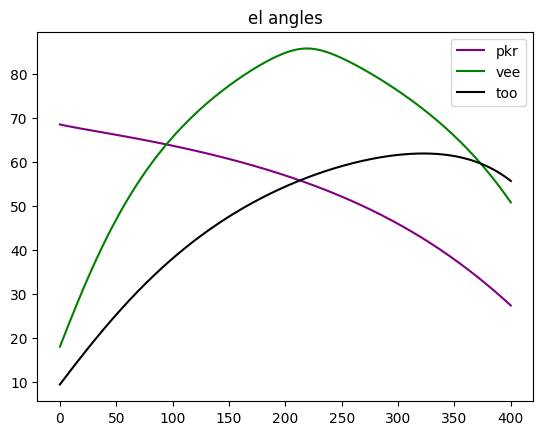

In [56]:
plt.plot(time,180*pkr_el/np.pi,label='pkr',color='purple')
plt.plot(time,180*vee_el/np.pi,label='vee',color='green')
plt.plot(time,180*too_el/np.pi,label='too',color='black')
plt.legend()
plt.title('el angles')

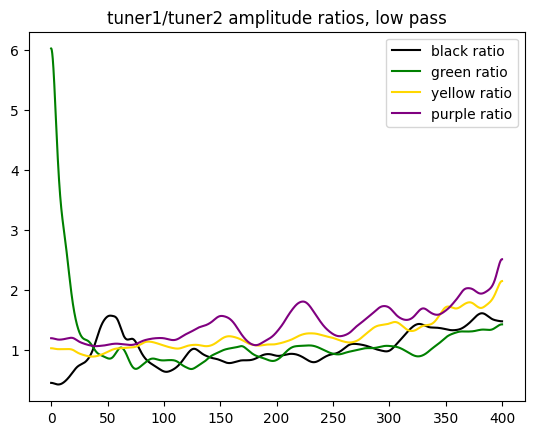

In [57]:
plt.plot(time,envb1/envb2,color='black',label='black ratio')
plt.plot(time,envg1/envg2,color='green',label='green ratio')
plt.plot(time,envy1/envy2,color='gold',label='yellow ratio')
plt.plot(time,envl1/envl2,color='purple',label='purple ratio')
plt.title('tuner1/tuner2 amplitude ratios, low pass')
plt.legend()

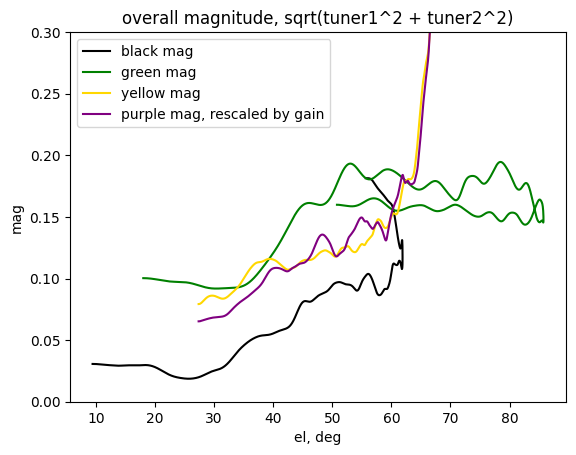

In [58]:
plt.plot((180/np.pi)*too_el,np.sqrt(envb1**2 + envb2**2),color='black',label='black mag')
plt.plot((180/np.pi)*vee_el,np.sqrt(envg1**2 + envg2**2),color='green',label='green mag')
plt.plot((180/np.pi)*pkr_el,np.sqrt(envy1**2 + envy2**2),color='gold',label='yellow mag')
plt.plot((180/np.pi)*pkr_el,np.sqrt(envl1**2 + envl2**2)*1.6487212707,color='purple',label='purple mag, rescaled by gain')
plt.title('overall magnitude, sqrt(tuner1^2 + tuner2^2)')
plt.ylim(0,0.3)
plt.xlabel('el, deg')
plt.ylabel('mag')
plt.legend()

In [59]:
# Now we calculate the B field in our new coordinate system
# Vertical part first, assume it points north:
# [np.cos(inc*np.pi/180),0,np.sin(inc*np.pi/180)]
# Add in the rotation into East:
#Bhat = np.asarray([np.cos(-inc*np.pi/180)*np.cos(-decl*np.pi/180),np.cos(-inc*np.pi/180)*np.sin(-decl*np.pi/180),np.sin(-inc*np.pi/180)])
Bhat = np.asarray([-np.cos(inc*np.pi/180)*np.cos(decl*np.pi/180),-np.cos(inc*np.pi/180)*np.sin(decl*np.pi/180),np.sin(inc*np.pi/180)])
B = Bmag*Bhat

In [60]:
# Now let's calculate look direction vectors for each of our sites, starting with Poker:
dx_pkr,dy_pkr,dz_pkr = newx_rocket-pkr_x,newy_rocket-pkr_y,newz_rocket-0
Bdl_pkr_0order = dx_pkr*B[0] + dy_pkr*B[1] + dz_pkr*B[2]
# Venitie is trivial
dx_vee,dy_vee,dz_vee = newx_rocket-0,newy_rocket-0,newz_rocket-0
Bdl_vee_0order = newx_rocket*B[0] + newy_rocket*B[1] + newz_rocket*B[2]
# Toolik
dx_too,dy_too,dz_too = newx_rocket-too_x,newy_rocket-too_y,newz_rocket-0
Bdl_too_0order = dx_too*B[0] + dy_too*B[1] + dz_too*B[2]

In [61]:
dec = 200

In [ ]:
# For the (decimated) flight path, find Bpar and L at each point

################################################################
######## Poker
################################################################
Bparvec = []
Lvec = []
for i in range(len(time[::dec])):
    Bpar,L = util.path_Bpar(np.asarray([pkr_x,pkr_y,0]),np.asarray([newx_rocket[::dec][i],newy_rocket[::dec][i],newz_rocket[::dec][i]]),4,date,plot=False)
    Bparvec.append(Bpar)
    Lvec.append(L)
Bparvec_pkr = np.asarray(Bparvec)
Lvec_pkr = np.asarray(Lvec)

# Resample onto undecimated path
Bparvec_pkr_interp = scipy.interpolate.CubicSpline(time[::dec],Bparvec_pkr)(time)
Lvec_pkr_interp = scipy.interpolate.CubicSpline(time[::dec],Lvec_pkr)(time)

################################################################
######## Venitie
################################################################

Bparvec = []
Lvec = []
for i in range(len(time[::dec])):
    Bpar,L = util.path_Bpar(np.asarray([vee_x,vee_y,0]),np.asarray([newx_rocket[::dec][i],newy_rocket[::dec][i],newz_rocket[::dec][i]]),4,date,plot=False)
    Bparvec.append(Bpar)
    Lvec.append(L)
Bparvec_vee = np.asarray(Bparvec)
Lvec_vee = np.asarray(Lvec)

# Resample onto undecimated path
Bparvec_vee_interp = scipy.interpolate.CubicSpline(time[::dec],Bparvec_vee)(time)
Lvec_vee_interp = scipy.interpolate.CubicSpline(time[::dec],Lvec_vee)(time)

################################################################
######## Toolik
################################################################

Bparvec = []
Lvec = []
for i in range(len(time[::dec])):
    Bpar,L = util.path_Bpar(np.asarray([too_x,too_y,0]),np.asarray([newx_rocket[::dec][i],newy_rocket[::dec][i],newz_rocket[::dec][i]]),4,date,plot=False)
    Bparvec.append(Bpar)
    Lvec.append(L)
Bparvec_too = np.asarray(Bparvec)
Lvec_too = np.asarray(Lvec)

Bparvec_too_interp = scipy.interpolate.CubicSpline(time[::dec],Bparvec_too)(time)
Lvec_too_interp = scipy.interpolate.CubicSpline(time[::dec],Lvec_too)(time)

Text(0.5, 1.0, 'LOS-integrated B dot dL along flight path')

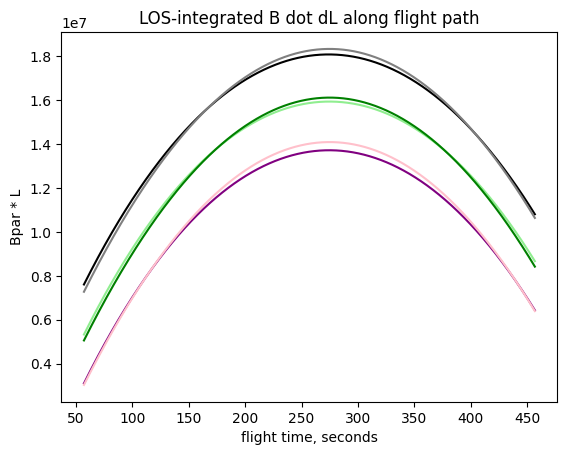

In [63]:
plt.plot(flighttime_radio,Bparvec_pkr_interp*Lvec_pkr_interp,color='purple')
plt.plot(flighttime_radio,Bdl_pkr_0order,color='pink')
plt.plot(flighttime_radio,Bparvec_vee_interp*Lvec_vee_interp,color='lightgreen')
plt.plot(flighttime_radio,Bdl_vee_0order,color='green')
plt.plot(flighttime_radio,Bparvec_too_interp*Lvec_too_interp,color='black')
plt.plot(flighttime_radio,Bdl_too_0order,color='gray')
plt.xlabel('flight time, seconds')
plt.ylabel('Bpar * L')
plt.title('LOS-integrated B dot dL along flight path')
#plt.plot(flighttime_radio,-bestfitparab*10**5,linewidth=2,color='blue',label='rotation, degrees, quadratic fit')

Text(0.5, 1.0, 'mean B// along line-of-sight, nT')

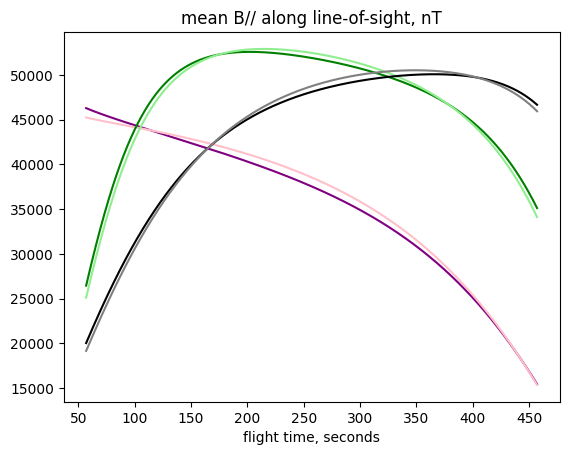

In [64]:
plt.plot(flighttime_radio,Bparvec_pkr_interp,color='purple')
plt.plot(flighttime_radio,Bdl_pkr_0order/np.sqrt(dx_pkr**2 + dy_pkr**2 + dz_pkr**2),color='pink')
plt.plot(flighttime_radio,Bparvec_vee_interp,color='green')
plt.plot(flighttime_radio,Bdl_vee_0order/np.sqrt(dx_vee**2 + dy_vee**2 + dz_vee**2),color='lightgreen')
plt.plot(flighttime_radio,Bparvec_too_interp,color='black')
plt.plot(flighttime_radio,Bdl_too_0order/np.sqrt(dx_too**2 + dy_too**2 + dz_too**2),color='gray')
#plt.plot(flighttime_radio,altresamp*100)
plt.xlabel('flight time, seconds')
plt.title('mean B// along line-of-sight, nT')


(-340.0, 340.0)

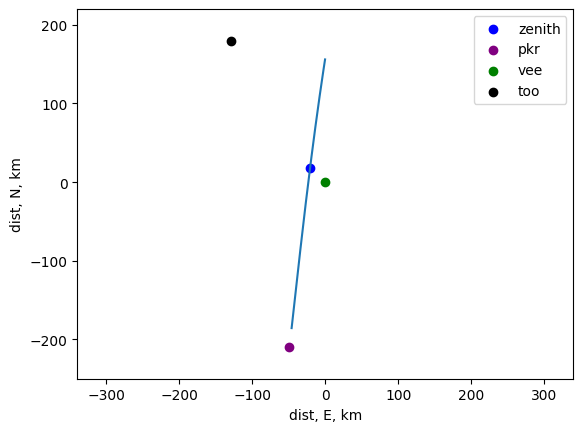

In [65]:
plt.plot(-newy_rocket,newx_rocket)
plt.scatter(-newy_rocket[np.argmax(newz_rocket)],newx_rocket[np.argmax(newz_rocket)],color='blue',label='zenith')


plt.scatter(-pkr_y,pkr_x,color='purple',label='pkr')
# plt.scatter(-newy_rocket[bestbind_pkr],newx_rocket[bestbind_pkr],color='purple')

plt.scatter(-vee_y,vee_x,color='green',label='vee')
# plt.scatter(-newy_rocket[bestbind_vee],newx_rocket[bestbind_vee],color='green')

plt.scatter(-too_y,too_x,color='black',label='too')
# plt.scatter(-newy_rocket[bestbind_too],newx_rocket[bestbind_too],color='black')

plt.xlabel('dist, E, km')
plt.ylabel('dist, N, km')

plt.legend()


plt.ylim(-250,220)
plt.xlim(-340,340)

(-255.0, 255.0)

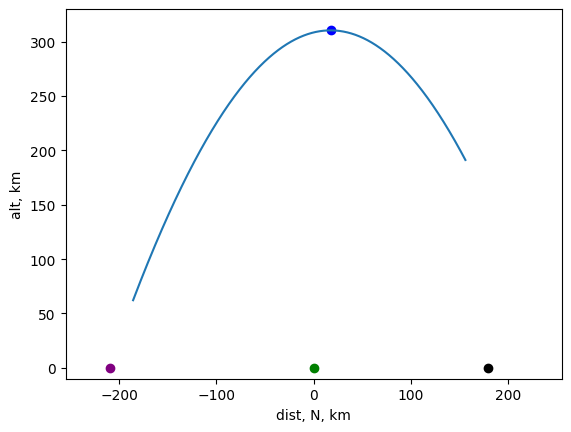

In [66]:
plt.plot(newx_rocket,newz_rocket)
plt.scatter(newx_rocket[np.argmax(newz_rocket)],newz_rocket[np.argmax(newz_rocket)],color='blue')


plt.scatter(pkr_x,0,color='purple')
#plt.scatter(newx_rocket[bestbind_pkr],newz_rocket[bestbind_pkr],color='purple')

plt.scatter(vee_x,0,color='green')
#plt.scatter(newx_rocket[bestbind_vee],newz_rocket[bestbind_vee],color='green')

plt.scatter(too_x,0,color='black')
#plt.scatter(newx_rocket[bestbind_too],newz_rocket[bestbind_too],color='black')


plt.xlabel('dist, N, km')
plt.ylabel('alt, km')
plt.ylim(-10,330)
plt.xlim(-255,255)

In [67]:
# Don't touch this, I calculated it on wolfram alpha...
# Something with mu_0 and the electron charge, I think

multconst = 3.33*10**11

Text(0.5, 1.0, 'TEC')

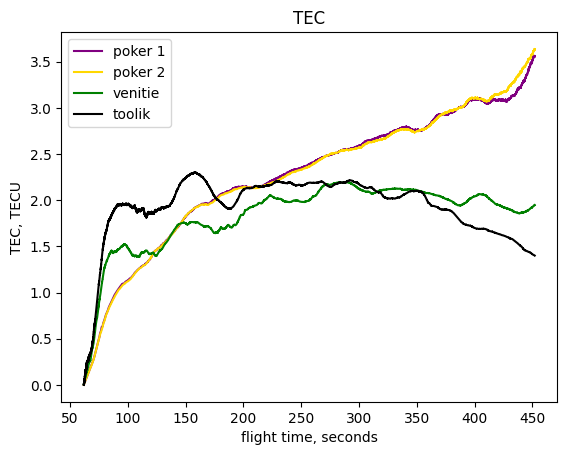

In [68]:
plt.ylabel('TEC, TECU')
plt.xlabel('flight time, seconds')
plt.plot(flighttime_radio[489:-489],-multconst*0.5*10**(-7)*(phaseoff_lav[489:-489]-phaseoff_lav[489])/(Bparvec_pkr_interp)[489:-489],color='purple',label='poker 1')
plt.plot(flighttime_radio[489:-489],-multconst*0.5*10**(-7)*(phaseoff_yellow[489:-489]-phaseoff_yellow[489])/(Bparvec_pkr_interp)[489:-489],color='gold',label='poker 2')
plt.plot(flighttime_radio[489:-489],-multconst*0.5*10**(-7)*(phaseoff_green[489:-489]-phaseoff_green[489])/(Bparvec_vee_interp)[489:-489],color='green',label='venitie')
plt.plot(flighttime_radio[489:-489],-multconst*0.5*10**(-7)*(phaseoff_black[489:-489]-phaseoff_black[489])/(Bparvec_too_interp)[489:-489],color='black',label='toolik')
plt.legend()
plt.title('TEC')

Text(0.5, 1.0, 'Path Length')

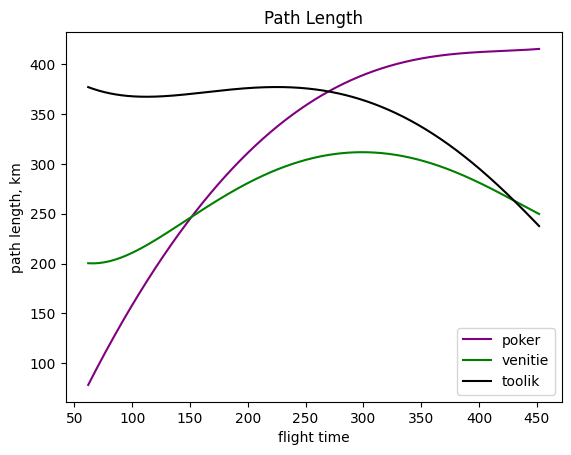

In [69]:
plt.ylabel('path length, km')
plt.xlabel('flight time')
plt.plot(flighttime_radio[489:-489],Lvec_pkr_interp[489:-489],color='purple',label='poker')
plt.plot(flighttime_radio[489:-489],Lvec_vee_interp[489:-489],color='green',label='venitie')
plt.plot(flighttime_radio[489:-489],Lvec_too_interp[489:-489],color='black',label='toolik')
plt.legend()
plt.title('Path Length')

Text(0.5, 1.0, 'overall mag dependence on rocket elevation angle')

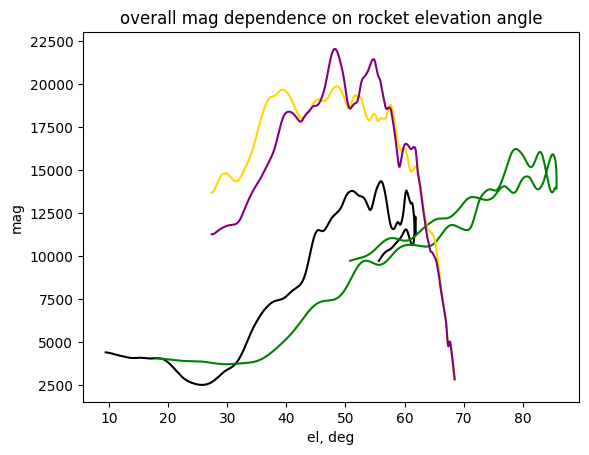

In [70]:
plt.plot((180/np.pi)*too_el,np.sqrt(envb1**2 + envb2**2)*Lvec_too_interp**2,color='black',label='black mag')
plt.plot((180/np.pi)*vee_el,np.sqrt(envg1**2 + envg2**2)*Lvec_vee_interp**2,color='green',label='green mag')
plt.plot((180/np.pi)*pkr_el,np.sqrt(envy1**2 + envy2**2)*Lvec_pkr_interp**2,color='gold',label='yellow mag')
plt.plot((180/np.pi)*pkr_el,np.sqrt(envl1**2 + envl2**2)*1.6487212707*Lvec_pkr_interp**2,color='purple',label='purple mag, rescaled by gain')
#plt.ylim(0,0.25)
plt.xlabel('el, deg')
plt.ylabel('mag')
plt.title('overall mag dependence on rocket elevation angle')
#plt.legend()

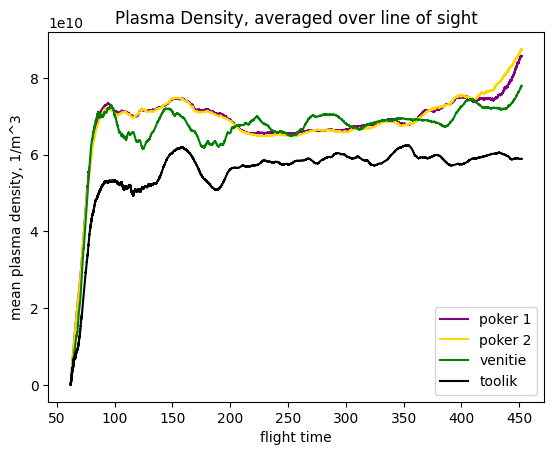

In [71]:
plt.ylabel('mean plasma density, 1/m^3')
plt.xlabel('flight time')
plt.plot(flighttime_radio[489:-489],-multconst*0.5*10**6*(phaseoff_lav[489:-489]-phaseoff_lav[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489],color='purple',label='poker 1')
plt.plot(flighttime_radio[489:-489],-multconst*0.5*10**6*(phaseoff_yellow[489:-489]-phaseoff_yellow[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489],color='gold',label='poker 2')
plt.plot(flighttime_radio[489:-489],-multconst*0.5*10**6*(phaseoff_green[489:-489]-phaseoff_green[489])/(Bparvec_vee_interp*Lvec_vee_interp)[489:-489],color='green',label='venitie')
plt.plot(flighttime_radio[489:-489],-multconst*0.5*10**6*(phaseoff_black[489:-489]-phaseoff_black[489])/(Bparvec_too_interp*Lvec_too_interp)[489:-489],color='black',label='toolik')
plt.title('Plasma Density, averaged over line of sight')
plt.legend()

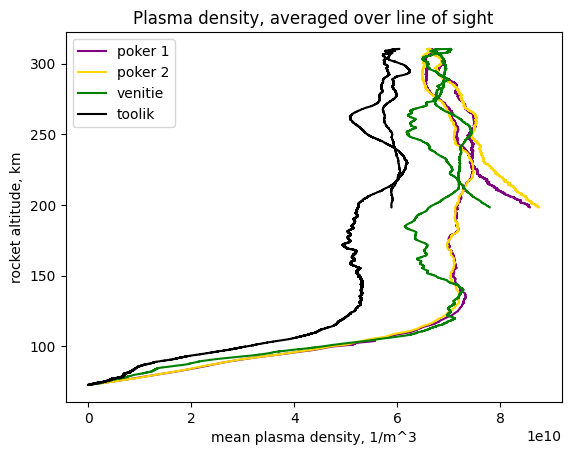

In [72]:
plt.xlabel('mean plasma density, 1/m^3')
plt.ylabel('rocket altitude, km')
plt.title('Plasma density, averaged over line of sight')
plt.plot(-multconst*0.5*10**6*(phaseoff_lav[489:-489]-phaseoff_lav[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489],altresamp[489:-489],color='purple',label='poker 1')
plt.plot(-multconst*0.5*10**6*(phaseoff_yellow[489:-489]-phaseoff_yellow[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489],altresamp[489:-489],color='gold',label='poker 2')
plt.plot(-multconst*0.5*10**6*(phaseoff_green[489:-489]-phaseoff_green[489])/(Bparvec_vee_interp*Lvec_vee_interp)[489:-489],altresamp[489:-489],color='green',label='venitie')
plt.plot(-multconst*0.5*10**6*(phaseoff_black[489:-489]-phaseoff_black[489])/(Bparvec_too_interp*Lvec_too_interp)[489:-489],altresamp[489:-489],color='black',label='toolik')
plt.legend()

/tmp/ipykernel_8103/709999908.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(-multconst*0.5*10**6*(phaseoff_lav[489:-489]-phaseoff_lav[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489]),altresamp[489:-489],color='purple')
/tmp/ipykernel_8103/709999908.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(-multconst*0.5*10**6*(phaseoff_yellow[489:-489]-phaseoff_yellow[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489]),altresamp[489:-489],color='gold')
/tmp/ipykernel_8103/709999908.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(-multconst*0.5*10**6*(phaseoff_green[489:-489]-phaseoff_green[489])/(Bparvec_vee_interp*Lvec_vee_interp)[489:-489]),altresamp[489:-489],color='green')
/tmp/ipykernel_8103/709999908.py:5: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(-multconst*0.5*10**6*(phaseoff_green[489:-489]-phaseoff_green[489])/(Bparvec_vee_interp*Lvec_vee_interp)[489:-489]),al

(10.0, 11.5)

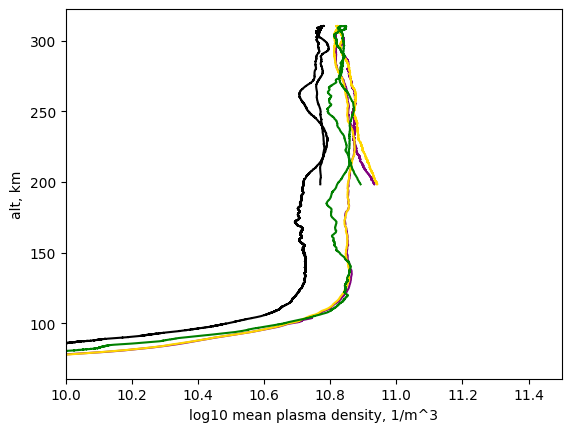

In [73]:
plt.xlabel('log10 mean plasma density, 1/m^3')
plt.ylabel('alt, km')
plt.plot(np.log10(-multconst*0.5*10**6*(phaseoff_lav[489:-489]-phaseoff_lav[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489]),altresamp[489:-489],color='purple')
plt.plot(np.log10(-multconst*0.5*10**6*(phaseoff_yellow[489:-489]-phaseoff_yellow[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489]),altresamp[489:-489],color='gold')
plt.plot(np.log10(-multconst*0.5*10**6*(phaseoff_green[489:-489]-phaseoff_green[489])/(Bparvec_vee_interp*Lvec_vee_interp)[489:-489]),altresamp[489:-489],color='green')
plt.plot(np.log10(-multconst*0.5*10**6*(phaseoff_black[489:-489]-phaseoff_black[489])/(Bparvec_too_interp*Lvec_too_interp)[489:-489]),altresamp[489:-489],color='black')
plt.xlim(10,11.5)

## We attempt a 1d "tomographic inversion" for part of the upleg

In [74]:
endind = int(np.round(np.where(np.diff(altresamp[489:-489])<0)[0][0]/2.3))

In [75]:
# Smooth and differentiate TEC curves

In [76]:
filterwid = 250

alttom = altresamp[489:-489][:endind]
timetom = flighttime_radio[489:-489][:endind]
lavphase = scipy.ndimage.gaussian_filter(-multconst*0.5*10**6*(phaseoff_lav[489:-489]-phaseoff_lav[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489],filterwid)[:endind]
yellowphase = scipy.ndimage.gaussian_filter(-multconst*0.5*10**6*(phaseoff_yellow[489:-489]-phaseoff_yellow[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489],filterwid)[:endind]
greenphase = scipy.ndimage.gaussian_filter(-multconst*0.5*10**6*(phaseoff_green[489:-489]-phaseoff_green[489])/(Bparvec_vee_interp*Lvec_vee_interp)[489:-489],filterwid)[:endind]
blackphase = scipy.ndimage.gaussian_filter(-multconst*0.5*10**6*(phaseoff_black[489:-489]-phaseoff_black[489])/(Bparvec_too_interp*Lvec_too_interp)[489:-489],filterwid)[:endind]

In [77]:
lp_cs = scipy.interpolate.CubicSpline(alttom,alttom*lavphase).derivative()(alttom)
yp_cs = scipy.interpolate.CubicSpline(alttom,alttom*yellowphase).derivative()(alttom)
gp_cs = scipy.interpolate.CubicSpline(alttom,alttom*greenphase).derivative()(alttom)
bp_cs = scipy.interpolate.CubicSpline(alttom,alttom*blackphase).derivative()(alttom)

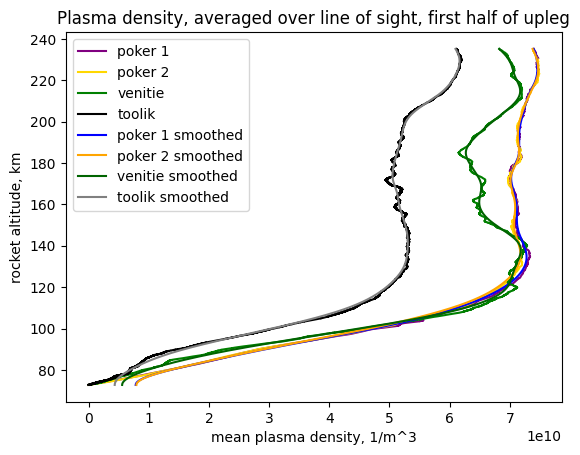

In [78]:
plt.xlabel('mean plasma density, 1/m^3')
plt.ylabel('rocket altitude, km')
plt.title('Plasma density, averaged over line of sight, first half of upleg')
plt.plot((-multconst*0.5*10**6*(phaseoff_lav[489:-489]-phaseoff_lav[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489])[:endind],altresamp[489:-489][:endind],color='purple',label='poker 1')
plt.plot((-multconst*0.5*10**6*(phaseoff_yellow[489:-489]-phaseoff_yellow[489])/(Bparvec_pkr_interp*Lvec_pkr_interp)[489:-489])[:endind],altresamp[489:-489][:endind],color='gold',label='poker 2')
plt.plot((-multconst*0.5*10**6*(phaseoff_green[489:-489]-phaseoff_green[489])/(Bparvec_vee_interp*Lvec_vee_interp)[489:-489])[:endind],(altresamp[489:-489])[:endind],color='green',label='venitie')
plt.plot((-multconst*0.5*10**6*(phaseoff_black[489:-489]-phaseoff_black[489])/(Bparvec_too_interp*Lvec_too_interp)[489:-489])[:endind],altresamp[489:-489][:endind],color='black',label='toolik')

plt.plot(lavphase,alttom,color='blue',label='poker 1 smoothed')
plt.plot(yellowphase,alttom,color='orange',label='poker 2 smoothed')
plt.plot(greenphase,alttom,color='darkgreen',label='venitie smoothed')
plt.plot(blackphase,alttom,color='gray',label='toolik smoothed')

plt.legend()

Text(0.5, 1.0, 'True density, smoothed, assuming only vertical variation ')

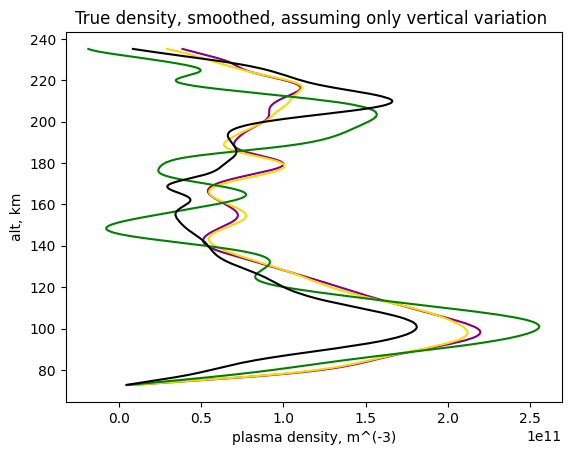

In [79]:
plt.plot(lp_cs,alttom,color='purple',label='poker 1')
plt.plot(yp_cs,alttom,color='gold',label='poker 2')
plt.plot(gp_cs,alttom,color='green',label='venitie')
plt.plot(bp_cs,alttom,color='black',label='toolik')
plt.xlabel('plasma density, m^(-3)')
plt.ylabel('alt, km')
plt.title('True density, smoothed, assuming only vertical variation ')

/tmp/ipykernel_8103/3683920782.py:3: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(gp_cs),alttom,color='green',label='venitie')


(10.0, 11.5)

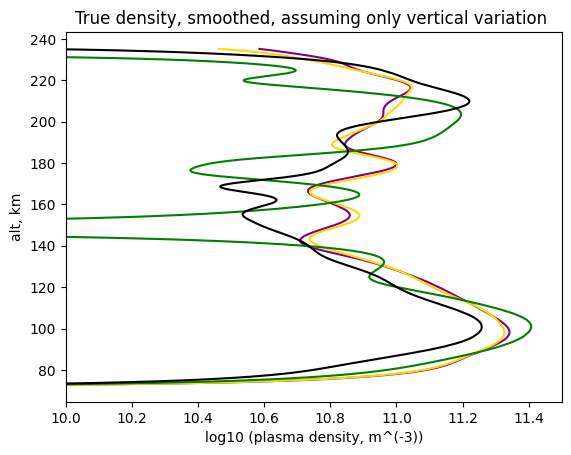

In [84]:
plt.plot(np.log10(lp_cs),alttom,color='purple',label='poker 1')
plt.plot(np.log10(yp_cs),alttom,color='gold',label='poker 2')
plt.plot(np.log10(gp_cs),alttom,color='green',label='venitie')
plt.plot(np.log10(bp_cs),alttom,color='black',label='toolik')
plt.xlabel('log10 (plasma density, m^(-3))')
plt.ylabel('alt, km')
plt.title('True density, smoothed, assuming only vertical variation ')
plt.xlim(10,11.5)